In [1]:
from platform import python_version
print(python_version())

3.11.14


### Tahoe

### Huggingface: tahoebio/Tahoe-x1-embeddings

https://github.com/tahoebio/tahoe-x1

Tahoe-x1: Scaling Perturbation-Trained Single-Cell Foundation Models to 3 Billion Parameters


#### Memory

That's not a general "64 GB isn't enough" — swap is fully exhausted at 2.0G, which means something asked for tens of GB in one allocation. Given where you are in the pipeline, the culprit is almost certainly load_tahoe_de, and the arithmetic says so:

The DE table is ~4.09e9 rows over ~75k conditions × ~54k genes. 

Filtering to pancreas doesn't help much — roughly 
- 6 lines × 379 drugs × ~4 doses × 54k genes ≈ 5e8 rows, 
- materialised in pandas with gene/drug/cell_line_id as object-dtype strings (~200 B/row) before pivot_table ever runs. 
- That's >100 GB. full_Z and consensus_cluster are megabytes by comparison.



In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

from scipy.stats import spearmanr


import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *


from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### Prism - development

In [8]:
import anndata as ad

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_prism

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism')

### Running prism

In [9]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (8.1 MB)
1918


In [10]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [11]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. If both had been mapped to malignant, purity would inflate. Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [12]:
res.cell_type_expression("Ductal cell type 1").shape

(1918, 153)

In [13]:
res.cell_type_expression("Ductal cell type 2").shape

(1918, 153)

### 2. theta is now fixed -> expand Z to every gene

In [14]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file


In [15]:
print(dfn_tumor.shape)
dfn_tumor.head(3)

(60616, 134)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
0,ENSG00000000003,TSPAN6,protein_coding,1486,2083,1558,546,1208,648,896,...,2506,442,38,299,77,158,394,659,1294,395
1,ENSG00000000005,TNMD,protein_coding,12,97,15,1,14,2,5,...,2,172,4,2,1,2,14,3,3,0
2,ENSG00000000419,DPM1,protein_coding,1330,1521,1499,986,1388,974,649,...,1638,940,1372,1008,1493,1059,922,839,717,1034


### Bulk - by geneid

In [16]:
df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=False, verbose=verbose)

#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


In [17]:
# cbio.plot_boxplot_expression(df_bulk, do_log10=True, fname_corr = "Expression across normal samples")

### Prism single-cell data reference - Peng 2019

In [18]:
force=False
verbose=True

fname = "count-matrix.txt"
adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

fname_ad = fname.replace('.txt', '.h5ad')
filename_ad = prism.root_prism / fname_ad
compression = "gzip"


verbose=True
fname_celltype = "all_celltype.txt"
adata_ct = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

adata_ct

57,530 cells x 24,005 genes | obs: []
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 57530 × 24005
    obs: 'cluster', 'cell_type', 'cell_state'

### Reference

In [19]:
ref, s2t = prism.pseudobulk_reference(adata_ct)

print(ref.shape)
ref.head(3)

(10, 23789)


gene,AL627309.1,AP006222.2,RP11-206L10.3,RP11-206L10.2,RP11-206L10.9,LINC00115,FAM41C,RP11-54O7.3,SAMD11,NOC2L,...,RP11-133N21.10,TMEM5-AS1,RP11-175P13.2,TBC1D4-AS1,RP11-329J18.3,RP11-227G15.2,RP11-686D22.5,KRT222,RP11-799B12.2,CTC-429C10.2
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,64.0,1612.0,42.0,22.0,30.0,214.0,102.0,103.0,1246.0,2337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,44.0,903.0,25.0,16.0,30.0,162.0,55.0,13.0,112.0,1719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophage cell,141.0,696.0,81.0,29.0,22.0,182.0,124.0,5.0,35.0,1293.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Bulk symbols

In [20]:
bulk_symbs = pd.read_csv(prism.root_prism / "bulk_matrix.tsv", sep="\t", index_col=0, usecols=[0])

### Get Harmonize

In [21]:
verbose=True

ref_new, df_to_from = prism.get_harmonize_reference_to_ensembl(ref=ref, verbose=verbose)

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.head(2)

Table opened ((10, 17540)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/ref_new_geneid.tsv'
Table opened ((23789, 5)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/to_from_table.tsv'
(10, 17540)
status
ok               17540
no_ensembl_id     6249
Name: count, dtype: int64


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [22]:
df_to_from2 = df_to_from[~pd.isnull(df_to_from.geneid)]
df_to_from2.head(3)

,ref_symbol,current_symbol,geneid,status,renamed
5,LINC00115,LINC00115,ENSG00000225880,ok,False
8,SAMD11,SAMD11,ENSG00000187634,ok,False
9,NOC2L,NOC2L,ENSG00000188976,ok,False


### gene_subset = select_genes(ref_new)

Informative-gene selection (analogue of BayesPrism's get.exp.stat + select.marker).  
Keeps genes with a strong one-vs-rest log2 fold change in the CPM-normalised pseudobulk reference.

Restricting to ~2-5k informative genes is what makes the fixed point both fast and stable;   
it barely changes theta but massively reduces the influence of protocol-driven genes.

In [23]:
gene_subset = prism.select_genes(ref_new)
len(gene_subset)

1918

### get bayesprism

In [24]:
verbose=True
force=False

meta_desc = dict(reference="Peng2019_CRA001160",
              cohorts=["TCGA-PAAD", "CPTAC3"],
              strand="unstranded",
              method="InstaPrism")

res = prism.run_bayesprism(df_bulk=df_bulk, ref=ref_new, state_to_type=s2t,
                           gene_subset=gene_subset, meta_desc=meta_desc, force=False, verbose=verbose)

type(res)

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (8.1 MB)


libs.prism_lib.DeconvResult

### Zfull ~ has 17540 genes like ref_new

- bulk has 27177 genes
- selecd ref_new 1918
- ref_new has 17540 genes

In [25]:
res.Z.shape, df_bulk.shape, ref_new.shape

((153, 10, 1918), (27177, 153), (10, 17540))

In [26]:
Zfull, gfull = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

(153, 10, 17540)


### Counts per cell

In [27]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, gfull, res, cell_state)
    dic[cell_state] = Z
    print(cell_state, Z.shape)

print("")
Z.head(3)


Fibroblast cell (17540, 153)
Stellate cell (17540, 153)
Macrophage cell (17540, 153)
Endothelial cell (17540, 153)
T cell (17540, 153)
B cell (17540, 153)
Ductal cell type 2 (17540, 153)
Endocrine cell (17540, 153)
Ductal cell type 1 (17540, 153)
Acinar cell (17540, 153)



,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,55.465,NaN,NaN,41.988,60.980,NaN,NaN,NaN,NaN,NaN,...,NaN,25.722,34.816,NaN,NaN,NaN,NaN,NaN,79.945,NaN
ENSG00000000005,0.207,NaN,NaN,0.029,0.237,NaN,NaN,NaN,NaN,NaN,...,NaN,0.147,0.032,NaN,NaN,NaN,NaN,NaN,0.040,NaN
ENSG00000000419,25.238,NaN,NaN,28.842,26.863,NaN,NaN,NaN,NaN,NaN,...,NaN,14.213,27.300,NaN,NaN,NaN,NaN,NaN,17.400,NaN


In [28]:
i=0
key = list(dic.keys())[i]

print(key)
Z = dic[key]
Z.head(3)

Fibroblast cell


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,32.066,58.012,43.613,32.366,34.058,31.881,35.654,54.328,30.481,40.203,...,NaN,16.647,16.364,NaN,NaN,NaN,27.003,NaN,53.037,NaN
ENSG00000000005,0.156,1.310,0.271,0.029,0.172,0.058,0.136,0.085,0.060,0.182,...,NaN,0.124,0.020,NaN,NaN,NaN,0.119,NaN,0.035,NaN
ENSG00000000419,41.234,43.095,42.380,62.828,42.398,43.955,25.719,43.317,42.273,46.569,...,NaN,25.995,36.263,NaN,NaN,NaN,21.046,NaN,32.622,NaN


### tumour-vs-normal design

The tumour-vs-normal design is also the standard one for deconvolution benchmarking:

your normals give an internal check that θ_malignant ≈ 0 where it should be,  
which is the only ground truth you have.

Worth confirming after the ENSG rebuild:

In [29]:
n_idx = [s for s in res.theta.index if s.startswith("N-")]
res.theta.loc[n_idx, "Ductal cell type 2"].describe()

count    1.500e+01
mean     2.915e-01
std      4.165e-01
min      5.772e-36
25%      2.223e-03
50%      6.589e-02
75%      5.626e-01
max      9.846e-01
Name: Ductal cell type 2, dtype: float64

In [30]:
n_idx = [s for s in res.theta.index if s.startswith("T-")]
res.theta.loc[n_idx, "Ductal cell type 2"].describe()

count    1.300e+02
mean     3.452e-01
std      2.559e-01
min      2.706e-22
25%      1.450e-01
50%      2.982e-01
75%      4.965e-01
max      1.000e+00
Name: Ductal cell type 2, dtype: float64

### AUC 

AUC is symmetric about 0.5 under label flipping. Your loop scored tumours as the positive class, so acinar's 0.318 means "acinar fraction predicts tumour" *poorly* — but the same number says acinar predicts **normal** at 0.682, because low acinar → tumour is itself a good rule.

So an AUC below 0.5 isn't weak discrimination; it's discrimination in the opposite direction. Distance from 0.5 is what measures separability:


| compartment | AUC | abs(AUC − 0.5) | direction | 
|---|---|---|---| 
| Fibroblast | 0.727 | 0.227 | up in tumour | 
| Acinar | 0.318 | 0.182 | **up in normal** | 
| Ductal-1 | 0.334 | 0.166 | up in normal | 
| Ductal-2 | 0.662 | 0.162 | up in tumour | 
| T cell | 0.346 | 0.154 | up in normal | 
| Endocrine | 0.489 | 0.011 | none | 


I compared 0.682 against Ductal-2's 0.662 to make the point that acinar *loss* separates tumour from normal slightly better than malignant *gain* does — which is the wrong ordering if θ_malignant were a good purity estimate.

Though I'd soften that claim now that they're side by side: 0.682 vs 0.662 is a difference of 0.02, well inside the noise at n=15 normals. The honest statement is that they're comparable, and that Fibroblast at 0.227 is the strongest single discriminator — consistent with desmoplasia being the most reliable bulk signature of PDAC.


Because they answer different questions, and I wanted the first.

**|AUC − 0.5|** measures *how much* separation there is, ignoring direction. It's the natural ranking when comparing compartments against each other, since a compartment at 0.32 and one at 0.68 are equally informative — one is depleted in tumours, the other enriched, both equally useful for telling the groups apart.

**1 − AUC** just relabels which class is positive. It's the right transform when you want to state the result in the other direction — as I did for acinar, to compare its 0.682 against Ductal-2's 0.662 on a common footing.

Applying `1 − AUC` uniformly to the whole table would have been wrong: it would turn Fibroblast's 0.727 into 0.273 and make the strongest discriminator look like the weakest.

Applying it *selectively* to sub-0.5 rows is a valid alternative and arguably more readable, since every value would then be ≥0.5 with a direction label. That's the same information as my table, folded differently:

| compartment | AUC (as "separability") | direction |
|---|---|---|
| Fibroblast | 0.727 | up in tumour |
| Acinar | 0.682 | up in normal |
| Ductal-1 | 0.666 | up in normal |
| Ductal-2 | 0.662 | up in tumour |

Same ordering as the |AUC − 0.5| column, since folding at 0.5 and measuring distance from 0.5 are monotonically equivalent. I used the deviation form because it keeps the "0 = useless" baseline visible — Endocrine at 0.011 reads more obviously as noise than 0.511 does.

### Ductal 2 - malignant

In [31]:
# has normal samples
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")
print(Zmal.shape)
Zmal.head(3)

(17540, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,30.065,55.029,40.439,32.081,32.77,31.182,33.480,52.445,28.622,41.104,...,NaN,20.901,18.993,NaN,NaN,NaN,39.159,NaN,54.487,NaN
ENSG00000000005,0.035,0.297,0.060,0.007,0.04,0.013,0.031,0.020,0.014,0.045,...,NaN,0.037,0.005,NaN,NaN,NaN,0.041,NaN,0.009,NaN
ENSG00000000419,34.732,36.725,35.302,55.946,36.65,38.623,21.696,37.567,35.662,42.774,...,NaN,29.322,37.812,NaN,NaN,NaN,27.419,NaN,30.108,NaN


In [32]:
ok = np.sum([1 if geneid in ref_new.columns.to_list() else 0 for geneid in df_bulk.index])
ok, len(df_bulk), ref_new.shape[1]

(17540, 27177, 17540)

In [33]:
bt = gene_map.reindex(df_bulk.index)["biotype"]
pd.crosstab(bt, df_bulk.index.isin(ref_new.columns), normalize="index").round(3)

col_0,False,True
biotype,,
lncRNA,0.884,0.116
miRNA,0.997,0.003
protein_coding,0.053,0.947


In [34]:
ref_new.head(3)

,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Macrophage cell,182.0,35.0,1293.0,66.0,47.0,918.0,19924.0,825.0,9.0,157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### MalignantCluster

In [35]:
import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.35.0


In [36]:
root_mprog_disease = cbio.root_mprog_disease
mal_cell_name = "Ductal cell type 2"
kmax = 8
no_decouple = True
is_tahoe = True


mc = pml.MalignantCluster(prism=prism, res=res, 
                          df_bulk=df_bulk, ref=ref_new, 
                          root_mprog_disease = root_mprog_disease,
                          mal_cell_name = mal_cell_name,
                          organ="Pancreas")

mc

### pc_theta_pearson and pc_theta_pearson_raw

**The computation.** Run PCA on the samples × genes matrix, take the first 5 principal components, and correlate each PC's sample scores with `theta_mal` (each sample's malignant fraction). `pcs[:, i]` is one number per sample for PC *i*; `theta_mal.values` is one number per sample. `np.corrcoef(...)[0,1]` pulls the off-diagonal — the Pearson r between them.

You get 5 numbers, one per PC. Each answers: *does this dominant axis of variation track tumour purity?*

**The two versions:**

| | matrix | meaning |
|---|---|---|
| `pc_theta_pearson_raw` | `logx` — log2-CPM before decoupling | how much purity is in the data |
| `pc_theta_pearson` | `Xc` — the matrix you actually cluster | how much purity survives into the analysis |

With `decouple_purity=False` they're the same matrix, so the numbers match — your `[-0.596, -0.205, 0.227, -0.359, -0.158]` versus `[-0.596, -0.205, 0.228, -0.359, -0.159]`. The tiny differences are HVG selection, which happens between the two calls.

With `decouple_purity=True`, `Xc` holds residuals from regressing on `theta_mal`, and residuals are **orthogonal to their regressors by construction**. So `pc_theta_pearson` becomes ~1e-15 — pure floating-point noise. It proves the arithmetic worked, nothing about your data. That's why 0.20.1 added the `_raw` version and the `pc_theta_note`: I originally had you reading a number that can only ever be zero.

**Your actual numbers matter.** PC1 at r = −0.596 means ~36% of the leading component's variance is shared with purity, and PC4 at −0.359 adds more. The sign says low-purity samples score high on PC1. Since `X` is what produced the consensus clustering, the 134-gene tumour axis, and the 6/119 splits, purity is a live confound in all of them.

Which is the concrete reason to run `decouple_purity=True` and compare — with the standing caveat that basal-like PDAC is genuinely lower-purity, so some of that r is biology you'd be deleting.

In [37]:
X, diag = mc.prepare_malignant_matrix(decouple_purity=False, 
                                      keep_genes=mc.program1_panel, drop_pattern=r"^N-")

print("Limited by n_hvg (highly variable genes)\n")
print(X.shape)
X.head(3)

excluded 22/153 samples by keep_samples/drop_pattern
Limited by n_hvg (highly variable genes)

(118, 2000)


,ENSG00000001084,ENSG00000001561,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,...,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278259,ENSG00000278535,ENSG00000278540
T-C3L-02890,6.780,5.736,7.171,5.541,8.460,7.229,3.217,7.004,6.726,7.630,...,6.132,6.505,8.483,5.027,4.268,2.718,4.797,7.108,3.834,7.867
T-C3L-03635,6.269,5.560,7.215,6.130,8.503,8.109,4.257,6.930,7.244,7.363,...,6.472,5.909,6.709,6.371,3.522,3.931,4.802,7.070,4.182,8.450
T-C3L-02701,5.989,7.098,7.601,7.242,8.451,7.274,4.592,7.107,7.048,6.365,...,6.274,5.258,7.830,4.836,4.575,3.923,5.229,7.101,4.260,7.952


### Scores

In [38]:
cmap = {
    "malignant":  "Ductal cell type 2",
    "fibroblast": "Fibroblast cell",     # whatever Peng calls stellate/CAF
    "macrophage": "Macrophage cell",
    "endothelial": "Endothelial cell",
}

X_mal2 = mc.compartment_matrix(cmap["malignant"],  min_share=0.3, min_counts=10)
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=0.3, min_counts=10)
print(X_mal2.shape, X_fib2.shape)

#---------- convert PROGRAMS to geneid -------------

scores, cov = mc.program_scores(compartment_map=cmap, samples=X.index.to_list())

print("\nPrograms x annotated genes")
print("--------------------------")
print(cov[["compartment","program","n_found","n_total"]])   # n_found should be 0 everywhere

(131, 8585) (129, 10853)

Programs x annotated genes
--------------------------
    compartment                 program  n_found  n_total
0     malignant                   basal       12       12
1     malignant               classical       12       12
2     malignant                     emt        6        6
3     malignant                  prolif        6        6
4     malignant          immune_evasion       12       12
5     malignant    antigen_presentation        6        7
6     malignant  desmoplastic_secretome       10       10
7     malignant    angiogenic_secretome        4        5
8    fibroblast                   myCAF        8        8
9    fibroblast                    iCAF        9        9
10   fibroblast                   apCAF        6        6
11   macrophage                      M1        5        6
12   macrophage                     TAM        7        7
13   macrophage                    SPP1        3        3
14   macrophage        mdsc_suppressive        7  

In [39]:
permutations = 5000
force=False
verbose=True

fname_corr=f"prog_corr_scores_x_malig_n{len(scores.index)}"
df_corr = mc.couple_compartments(scores=scores, fname_corr=fname_corr, cell_name=mc.mal_cell_name, n_perm=permutations, force=force, verbose=verbose)
print(df_corr.shape)
df_corr.head(3)

Table opened ((139, 6)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/deconv/prog_corr_scores_x_malig_n118_n_perm_5000_ctr_theta_True.tsv'
(139, 6)


,program_a,program_b,r,p_perm,n,fdr
0,fibroblast.iCAF,endothelial.activated,0.466,2.000e-04,63,0.003
1,malignant.immune_evasion,fibroblast.iCAF,0.412,2.000e-04,112,0.003
2,malignant.immune_evasion,fibroblast.apCAF,0.414,2.000e-04,112,0.003


In [40]:
print(scores.shape)
S = scores.dropna(axis=1, how="all").copy()
print(S.shape)
S.head(3)


(118, 20)
(118, 20)


,malignant.basal,malignant.classical,malignant.emt,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,malignant.angiogenic_secretome,fibroblast.myCAF,fibroblast.iCAF,fibroblast.apCAF,macrophage.M1,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.lymphatic,endothelial.activated,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.136,0.270,-0.011,0.018,-0.356,-1.478,-0.158,-0.772,-0.533,-0.467,-1.016,NaN,NaN,NaN,NaN,0.998,-0.347,-1.684,-0.406,-0.066
T-C3L-00589,-0.203,0.006,0.206,-0.697,-0.302,-0.211,-0.120,-0.988,-0.263,-0.059,-0.745,-0.891,0.095,-0.64,-0.655,-0.772,-0.433,-1.188,-0.209,-0.205
T-C3L-00625,-0.034,0.441,-0.184,-0.051,-0.340,-1.349,-0.066,-0.002,-0.233,-0.112,-0.542,NaN,NaN,NaN,NaN,1.098,0.404,-1.042,-0.475,-0.121


### axis_modality: is each axis one cloud or two? BIC of a 1- vs 2-component Gaussian.

**Decisive for interpretation.**

If an axis is unimodal, states carved from it are tails of a continuum, not phenotypes: 
- valid as a stratification,
- but you cannot call them subtypes, 
- and a sample near the boundary has no stable assignment.

### delta_bic

> delta_bic = BIC(1 comp) - BIC(2 comp). 

- positive favours two components; the usual reading is:
  - \>10 strong,
  - 2-10 weak, 
  - <2 negligible.
  
`min_weight` guards the case where the 2-component fit wins only by devoting a tiny component to outliers.

In [41]:
mc.axis_modality(scores)

,axis,n,delta_bic,min_component_weight,separation_sd,skew,verdict
0,malignant.axis_basal_minus_classical,118,16.7,0.225,1.72,1.38,bimodal
1,fibroblast.axis_myCAF_minus_iCAF,112,19.9,0.071,5.16,-1.03,weak/outlier-driven


In [42]:
coh = pd.Series(np.where(scores.index.str.contains("TCGA"), "TCGA", "CPTAC"),  index=scores.index)

for name in ["TCGA", "CPTAC"]:
    idx = list(scores.index[coh == name])
    sc_c, _ = mc.program_scores(compartment_map=cmap, samples=idx)
    print(name, len(idx))
    print(mc.axis_modality(sc_c).to_string(index=False))
    print("\n----------------------------------\n")

TCGA 74
                                axis  n  delta_bic  min_component_weight  separation_sd  skew             verdict
malignant.axis_basal_minus_classical 74        6.7                 0.027           6.15  1.53 weak/outlier-driven
    fibroblast.axis_myCAF_minus_iCAF 68       11.2                 0.153           3.42 -1.11             bimodal

----------------------------------

CPTAC 44
                                axis  n  delta_bic  min_component_weight  separation_sd  skew  verdict
malignant.axis_basal_minus_classical 44       -1.5                 0.194           2.74  0.99 unimodal
    fibroblast.axis_myCAF_minus_iCAF 44      -11.1                 0.488           1.64 -0.42 unimodal

----------------------------------



### "prolif" x "iCAF"

In [43]:
force=False
verbose=False

for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)

    fname_corr=f"prog_corr_scores_x_malig_for_{name}_n{len(sc_c.index)}"
    R = mc.couple_compartments(scores=sc_c, fname_corr=fname_corr, cell_name=mc.mal_cell_name, n_perm=permutations, force=force, verbose=verbose)

    # and "_minus" not in x.program_b
    print(name, '\n', R[R.apply(lambda x: "prolif" in x.program_a+x.program_b
                          and "iCAF" in x.program_a+x.program_b, axis=1)][["program_a", "program_b", "n", "r","p_perm","fdr"]].to_string(index=False))

TCGA 
        program_a                        program_b  n      r    p_perm   fdr
malignant.prolif                  fibroblast.iCAF 68 -0.458 2.000e-04 0.014
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 68  0.398 9.998e-04 0.035
CPTAC 
        program_a                        program_b  n      r    p_perm   fdr
malignant.prolif                  fibroblast.iCAF 44 -0.505 9.998e-04 0.035
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 44  0.175 2.601e-01 0.657


The core coupling replicates cleanly and is now robust to everything we've thrown at it:

| | r | FDR |
|---|---|---|
| TCGA (n=74) | **−0.458** | 0.023 |
| CPTAC (n=44) | **−0.505** | 0.035 |

**Same sign, near-identical magnitude, independently significant, θ-controlled, and now on a corrected reference with ~990 recovered genes, a rebuilt marker set and ENSG identifiers. That's a genuine finding: malignant proliferation co-occurs with iCAF-depleted stroma.**

The second row in each block is the same relationship read on the `myCAF_minus_iCAF` contrast (positive, since iCAF is the negative pole). It's significant in TCGA (r=0.398) but not CPTAC (r=0.175, FDR 0.646) — so report the direct `prolif`↔`iCAF` pair, not the axis version. The axis adds myCAF variation as noise without adding signal.

Worth noting *why* this one survived when everything else didn't. It's a **negative** correlation, and the shared-bulk component that inflates `zm`/`zf` to r≈0.93 is positive by construction. An artifact from that source can't produce a negative coupling. That's a structural argument for its validity, independent of the replication.

Two things I'd still do before writing it up.

Check it isn't purity in disguise — `couple_compartments` controls θ by default, but a direct look is cheap:

And be explicit that it's correlational and undirected. Bulk data cannot say whether proliferative tumours suppress iCAFs, iCAFs restrain proliferation, or both follow from something else. The mechanistic literature would let you argue either way — which is exactly why the claim should stay at co-occurrence.

In [44]:
force=False
verbose=False

for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)

    fname_corr=f"prog_corr_scores_x_malig_for_{name}_n{len(sc_c.index)}"
    R = mc.couple_compartments(scores=sc_c, fname_corr=fname_corr, cell_name=mc.mal_cell_name, control_theta=False, n_perm=permutations, force=force, verbose=verbose)
    if name == 'TCGA':
        R1 = R.copy()
    else:
        R2 = R.copy()

    # and '_minus_' not in x.program_b
    print(name, "\n", R[R.apply(lambda x: "prolif" in x.program_a+x.program_b
                          and x.program_b.endswith("iCAF"), axis=1)][["program_a", "program_b", "n", "r","fdr"]].to_string(index=False))

TCGA 
        program_a                        program_b  n      r   fdr
malignant.prolif                  fibroblast.iCAF 68 -0.462 0.028
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 68  0.428 0.046
CPTAC 
        program_a                        program_b  n      r   fdr
malignant.prolif                  fibroblast.iCAF 44 -0.521 0.028
malignant.prolif fibroblast.axis_myCAF_minus_iCAF 44  0.171 0.692


In [45]:
for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)
    
    x, y = sc_c["malignant.prolif"], sc_c["fibroblast.iCAF"]

    ok = x.notna() & y.notna()
    boot = [spearmanr(*zip(*[(x[ok].iloc[i], y[ok].iloc[i])
            for i in np.random.default_rng(s).integers(0, ok.sum(), ok.sum())]))[0]
            for s in range(500)]
    
    print(f"{name:6} r={spearmanr(x[ok],y[ok])[0]:.3f}  95% CI [{np.percentile(boot,2.5):.3f}, {np.percentile(boot,97.5):.3f}]")


TCGA   r=-0.462  95% CI [-0.655, -0.216]
CPTAC  r=-0.521  95% CI [-0.693, -0.277]


Both CIs exclude zero comfortably and overlap heavily — that's the cleanest evidence you've had for anything in this study.

| cohort | r | 95% CI |
|---|---|---|
| TCGA (n=74) | −0.462 | [−0.655, −0.216] |
| CPTAC (n=44) | −0.521 | [−0.693, −0.277] |

Two independent estimates, non-overlapping datasets, consistent point estimates. Lead with these rather than FDR — a bootstrap CI is the honest summary when the test was one of ~340, and the replication carries the inference regardless of which correction you quote.

Robust to: cohort, reference version (pre/post ENSG harmonisation, ~990 recovered genes, rebuilt marker set), θ control, and identifier scheme. Negative sign, so not producible by the shared-bulk component.

The result: **malignant proliferation is inversely associated with inflammatory CAF content in deconvolved PDAC transcriptomes.**

Three caveats to carry into the writeup, none of which undermine it:

- **Correlational and undirected.** Bulk cannot distinguish proliferative tumours suppressing iCAFs from iCAFs restraining proliferation, or a common upstream cause.
- **One reference.** Every compartment comes from a single Peng-2019 fit; a reference misspecification propagates to all of them, and nothing internal detects it. A second reference — snRNA-seq, which would also raise your 11.6% lncRNA ceiling — would be the strongest possible validation.
- **Compartment separation is partial.** `zm` vs `zf` at r ≈ 0.93 means most of each matrix is shared. The contrast structure of program scores is what makes this measurable, and it's worth saying so explicitly.

Alongside the replicated negative on discrete subtypes, that's a coherent paper: two continuous compartment axes, no discrete subtypes in either cohort, and one reproducible tumour–stroma association.


### compare_coupled_compartments()

In [46]:
program_list = ['TCGA', 'CPTAC']

df_meta_coup = mc.compare_coupled_compartments(program_list=program_list, coh=coh, cmap=cmap, 
                                          scores=scores, n_perm=permutations, force=force, verbose=verbose)
print(df_meta_coup.shape)
df_meta_coup.head(3)

(139, 18)


,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,z_het,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant
0,malignant.antigen_presentation,fibroblast.apCAF,0.486,2.000e-04,68,0.014,0.167,2.795e-01,44,0.673,1.819,0.069,0.391,0.372,5.747e-05,3.995e-03,0.698,True
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,0.308,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.000,True
2,malignant.immune_evasion,fibroblast.iCAF,0.425,3.999e-04,68,0.019,0.212,1.698e-01,44,0.576,1.196,0.232,0.361,0.346,1.994e-04,9.240e-03,0.301,True


In [47]:
df_meta_ok = df_meta_coup[(df_meta_coup.fdr_meta < 0.10) & (df_meta_coup.r_meta.abs() >= 0.25) & df_meta_coup.concordant]
df_meta_ok = df_meta_ok.sort_values(['program_a', 'program_b'])
df_meta_ok

,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,z_het,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant
64,fibroblast.apCAF,endothelial.activated,0.152,3.757e-01,35,0.798,0.607,7.998e-04,28,0.035,-2.064,0.039,0.395,0.376,2.869e-03,4.431e-02,0.765,True
38,fibroblast.iCAF,endothelial.activated,0.253,1.432e-01,35,0.510,0.635,2.000e-04,28,0.014,-1.844,0.065,0.474,0.442,3.433e-04,1.193e-02,0.706,True
10,malignant.angiogenic_secretome,macrophage.TAM,-0.473,7.798e-03,32,0.099,-0.229,2.314e-01,29,0.657,-1.041,0.298,-0.381,-0.364,4.728e-03,5.975e-02,0.077,True
0,malignant.antigen_presentation,fibroblast.apCAF,0.486,2.000e-04,68,0.014,0.167,2.795e-01,44,0.673,1.819,0.069,0.391,0.372,5.747e-05,3.995e-03,0.698,True
108,malignant.antigen_presentation,macrophage.M1,0.050,7.788e-01,32,0.974,0.663,2.000e-04,29,0.014,-2.767,0.006,0.403,0.383,2.770e-03,4.431e-02,0.869,True
15,malignant.desmoplastic_secretome,endothelial.lymphatic,-0.373,2.500e-02,36,0.196,-0.396,3.959e-02,28,0.393,0.102,0.919,-0.404,-0.383,2.102e-03,4.174e-02,0.000,True
6,malignant.immune_evasion,endothelial.activated,0.459,5.399e-03,36,0.096,0.373,5.139e-02,28,0.453,0.394,0.694,0.451,0.423,5.943e-04,1.652e-02,0.000,True
9,malignant.immune_evasion,fibroblast.apCAF,0.338,7.199e-03,68,0.099,0.178,2.428e-01,44,0.657,0.861,0.389,0.285,0.278,3.298e-03,4.584e-02,0.000,True
2,malignant.immune_evasion,fibroblast.iCAF,0.425,3.999e-04,68,0.019,0.212,1.698e-01,44,0.576,1.196,0.232,0.361,0.346,1.994e-04,9.240e-03,0.301,True
3,malignant.prolif,fibroblast.axis_myCAF_minus_iCAF,0.398,9.998e-04,68,0.035,0.175,2.601e-01,44,0.657,1.225,0.221,0.326,0.315,7.774e-04,1.801e-02,0.334,True


In [48]:
df_meta_ok = df_meta_coup[(df_meta_coup.p_perm_t < 0.05) & (df_meta_coup.p_perm_c < 0.05) &
                     df_meta_coup.concordant & (df_meta_coup.r_meta.abs() >= 0.25)]
df_meta_ok = df_meta_ok.sort_values(['program_a', 'program_b'])
df_meta_ok

,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,z_het,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant
15,malignant.desmoplastic_secretome,endothelial.lymphatic,-0.373,2.500e-02,36,0.196,-0.396,3.959e-02,28,0.393,0.102,0.919,-0.404,-0.383,2.102e-03,4.174e-02,0.0,True
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,0.308,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.0,True


### Coupled & NNLS non-prior biased

In [49]:
th_nnls = prism.nnls_deconvolve(df_bulk, ref_new, genes=gene_subset)

th_em   = res.theta

common = th_em.index.intersection(th_nnls.index)
df_conc = pd.DataFrame({
    "nnls_spearman":  {c: th_em.loc[common, c].corr(th_nnls.loc[common, c], method="spearman")
                  for c in th_em.columns},
    "nnls_pearson":   {c: th_em.loc[common, c].corr(th_nnls.loc[common, c])
                  for c in th_em.columns},
    "nnls_mean_em":   th_em.loc[common].mean(),
    "nnls_mean_nnls": th_nnls.loc[common].mean(),
    "nnls_n":         {c: (th_em.loc[common, c].notna() & th_nnls.loc[common, c].notna()).sum()
                  for c in th_em.columns},
}).sort_values("nnls_spearman", ascending=False).round(3)

# each coupling has two compartments -> map both, gate on the weaker one
cell_of = {k: v for k, v in cmap.items()}            # program key -> cell type
sp = df_conc["nnls_spearman"]

def conc_of(prog):                                   # "malignant.prolif" -> spearman
    return sp.get(cell_of.get(prog.split(".")[0]), np.nan)

df_meta_coup["nnls_prog_a"]   = df_meta_coup.program_a.map(conc_of)
df_meta_coup["nnls_prog_b"]   = df_meta_coup.program_b.map(conc_of)
df_meta_coup["nnls_min"] = df_meta_coup[["nnls_prog_a", "nnls_prog_b"]].min(axis=1)

df_meta_coup.head(3)


,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,...,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant,nnls_prog_a,nnls_prog_b,nnls_min
0,malignant.antigen_presentation,fibroblast.apCAF,0.486,2.000e-04,68,0.014,0.167,2.795e-01,44,0.673,...,0.069,0.391,0.372,5.747e-05,3.995e-03,0.698,True,0.864,0.932,0.864
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,...,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.000,True,0.864,0.932,0.864
2,malignant.immune_evasion,fibroblast.iCAF,0.425,3.999e-04,68,0.019,0.212,1.698e-01,44,0.576,...,0.232,0.361,0.346,1.994e-04,9.240e-03,0.301,True,0.864,0.932,0.864


In [50]:
df_meta_ok = df_meta_coup[
    (df_meta_coup.p_perm_t < 0.1) & (df_meta_coup.p_perm_c < 0.1) &   # both cohorts, not just meta
     df_meta_coup.concordant &
    (df_meta_coup.r_meta.abs() >= 0.2) &
    (df_meta_coup.nnls_min > 0.2)
].sort_values("fdr_meta")

df_meta_ok

,program_a,program_b,r_t,p_perm_t,n_t,fdr_t,r_c,p_perm_c,n_c,fdr_c,...,p_het,z_meta,r_meta,p_meta,fdr_meta,I2,concordant,nnls_prog_a,nnls_prog_b,nnls_min
1,malignant.prolif,fibroblast.iCAF,-0.458,2.000e-04,68,0.014,-0.505,9.998e-04,44,0.035,...,0.758,-0.518,-0.476,9.518e-08,1.323e-05,0.0,True,0.864,0.932,0.864


### Signature x Gene Expression - clusterization

sig_acinar_fibroblast.py
========================

Wide signatures for the two compartments that satisfy the present-in-both-states
criterion, structured as :class:`SubProgram` leaves for ``programs_v2.py``.

Two tiers per compartment:

* **CORE**   -- high compartment specificity, safe for scoring and for
  tumour-vs-normal contrasts.
* **FLAGGED** -- real markers, but each carries an attribution or interpretation
  risk that matters in a deconvolution setting. Kept separate so you can score
  with and without them and see whether conclusions move. Every flagged gene
  carries its reason in ``RISK``.

Symbols are current HGNC. Three renames that bit this pipeline before are
already applied: CTGF -> CCN2, CYR61 -> CCN1, MIST1 -> BHLHA15. Run them through
your ENSG harmonisation before use.

Reliability note
----------------
Score reliability rises with signature length (Spearman-Brown) *only* for genes
with non-zero per-gene reliability. Adding an ambiguous gene lowers rho_1 and can
net-decrease the score's reliability. Score CORE alone first, then CORE+FLAGGED,
and compare split-half reliability -- if it drops, the flagged tier is noise for
your cohort.


In [51]:
from __future__ import annotations

### Can we proceed our calculus using Acinar and Fibroblast?

Both are present in normal and in PDAC — so the contrast is defined for each. But the pair has a specific property that makes it the wrong choice for a cross-compartment correlation, and a good choice for something else.

#### Mirror-image estimability

Acinar is ~85% of normal pancreas and depleted in tumor. Fibroblast is a few percent in normal and 30–60% in tumor. Each compartment has one well-determined arm and one prior-dominated arm, and they're opposite arms:

| | normal | tumor |
|---|---|---|
| acinar | excellent | poor |
| fibroblast | poor | excellent |

For LFC, that means neither is limited by the same thing, and neither is clean end-to-end. For correlation across tumor samples — which is what your framework actually computes — the acinar side is the weak one, same failure as macrophage and endothelial.

#### The pair *is* the cellularity axis

This is the decisive objection. 
1. A tumor sample with more residual normal parenchyma has more acinar and less stroma; 
2. one with more desmoplasia has the reverse. 
3. **θ_acinar and θ_fibroblast** are the two poles of a single compositional axis, so **their correlation approaches −1** by construction, before any biology.

You've already characterized this axis. **Program-1 was defined as parenchyma-depleted** — parenchyma is acinar. Your Program-1/Program-2 split reflected tumor cellularity rather than the Moffitt basal-classical axis, which was the whole point of that finding. An acinar↔fibroblast correlation would re-derive it, with a strong negative r that looks like a result.


#### Acinar's peculiar signal properties

**Digestive enzyme** transcripts — PRSS1, CPA1, CTRB1/2, CELA, CLPS, AMY2A — are among the most abundant in any human tissue. 

- Three consequences:
  - Good: acinar ψ may be better determined at low fraction than the abundance suggests, because the marker signal is enormous. Acinar is not simply another low-fraction compartment.

  - Bad: a few percent acinar shifts the library composition for everything else. In CPM space, acinar content changes the denominator for every other compartment's genes — a compositional effect on the whole matrix, not just on acinar.

  - Worse: pancreas is RNase-rich, so RNA integrity is poor and variable, and acinar transcripts are what degrade most visibly. Acinar fraction partly tracks RIN and ischemic time. Given the strandedness episode, a compartment that co-varies with a technical quality metric deserves suspicion before interpretation.

There's also an identity problem: acinar-to-ductal metaplasia means acinar cells in tumor-adjacent tissue are transdifferentiating, not resting. "Acinar in tumor" isn't the same entity as "acinar in normal," so the same-compartment-different-state framing your criterion assumes doesn't quite hold.

#### What acinar is genuinely good for

Three uses, all stronger than treating it as a correlation partner:

**Purity covariate.** θ_acinar is a direct estimate of residual normal parenchyma — arguably a better proxy for what's contaminating your tumor samples than ESTIMATE or ABSOLUTE, because it's measured in the same pipeline. Partial it out of every cross-compartment correlation and see which survive. That's the test that would settle how much of your 139-row table is cellularity.

**Negative control for leakage.** PRSS1 and CPA1 should have near-zero share in the fibroblast compartment. If `gene_compartment_share_nnls` puts them there, you have direct evidence of misattribution, with an unambiguous ground truth — no acinar gene has any business in a CAF profile. That's a cleaner leakage test than anything built on ambiguous genes.

**Normal-arm anchor.** Acinar is the one compartment where ψ_normal is well-determined, so it's the place to validate that your normal deconvolution is behaving at all before trusting the stromal normal estimates.

If the goal is a second measurable coupling alongside prolif↔iCAF, fibroblast paired with the *malignant* compartment remains the better bet — both are high-abundance in tumor, and that pairing isn't collinear with the cellularity axis in the way acinar↔fibroblast is by construction.

### The two problems

#### Argument

There are two big problems with Acinar cells: 1) RNA integrity and 2) acinar-to-ductal metaplasia. That means that x% of the RNA failed to be detected due to RNA integrity, and part of the acinar cell transdifferentiates into ductal. However, besides low counts, since our goal is to cluster by subtype, the final result should not disturb the analysis.

#### Claude answer

**The argument would hold if these were uniform attenuation.** Clustering by correlation distance is invariant to per-sample scaling, so a constant loss of x% of acinar RNA in every sample would indeed wash out. But neither problem has that form, and one of them targets clustering specifically.

#### RIN is not a per-sample constant

Degradation is 3'-biased and transcript-length-dependent. It doesn't multiply a sample's profile by a scalar — it reshuffles the relative ranking of genes *within* a sample, favoring short transcripts and 3' regions. Per-sample normalization cannot remove that, because it isn't a per-sample effect. And RIN varies across samples with ischemic time and collection site, so in TCGA it tends to be confounded with tissue source site.

There's an amplification specific to pancreas. Acinar transcripts are the overwhelming majority of pancreatic mRNA mass, so when they degrade preferentially, **every other gene's CPM rises** — the denominator shrank. A low-RIN sample therefore looks like it has less parenchyma and relatively more stroma and tumor.

That is indistinguishable from higher tumor cellularity. Which is the axis you already identified as Program-1 versus Program-2. So RIN doesn't just perturb acinar; it loads onto the dominant axis of your entire dataset, through the normalization rather than through acinar's own values.

#### ADM isn't loss, it's transfer

Transdifferentiating acinar cells don't disappear from the data — they move. They acquire SOX9, KRT19, ONECUT1, CFTR and get assigned to the ductal compartment. Three consequences, none of them noise-like:

The ductal/malignant compartment gets non-malignant cells folded in, so purity is overestimated and ψ_malignant becomes a mixture. The acinar compartment loses precisely its least-typical cells, so surviving acinar ψ is biased toward the quiescent end. And ADM extent tracks peritumoral inflammation, which tracks stromal activation — so ADM introduces a *structured* coupling between the ductal and fibroblast compartments, in the same direction real biology would.

A directional confound that mimics the signal is worse than random loss, not better.

#### The part that bears directly on clustering

Low counts aren't benign for your specific goal. They produce zero-inflation, and zero-inflation meets the ψ ≥ 0 boundary — which is result (c) from the simulation: truncation generated ΔBIC over 1800 from a distribution with no biological bimodality at all.

So the failure mode isn't attenuation, which clustering tolerates. It's **manufactured cluster structure**, which is the one thing clustering cannot tolerate. A block of acinar rows where some samples sit at the detection floor and others don't will separate those samples cleanly, and the separation will look excellent by every internal validity metric.

#### An asymmetric test you can run cheaply

You already established, by three methods, that there is no discrete structure in this data. That gives you a strong prior and a clean diagnostic:

**If adding the acinar block now produces discrete clusters, the acinar artifacts are the first hypothesis, not newly revealed biology.** Run the clustering with and without acinar rows. If structure appears only with them, check in this order — per-sample zero fraction among acinar genes, RIN or transcript integrity from the biospecimen metadata, tissue source site, and ADM marker score within the acinar compartment. Any one of those tracking the partition settles it.

That test costs one extra clustering run and it's decisive either way. If clusters survive without acinar, you've gained a real result. If they only appear with it, you've avoided a second Program-1.


In [52]:
df_theta = res.theta
df_theta.head(3)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.603,8.666e-03,0.025,0.029,8.828e-73,0.018,0.105,1.176e-152,1.083e-01,0.104
T-C3L-03635,0.760,5.456e-03,0.016,0.028,2.978e-163,0.008,0.183,4.146e-105,2.173e-72,0.000
T-C3L-02701,0.763,1.275e-08,0.027,0.015,1.957e-222,0.005,0.175,1.414e-02,1.685e-148,0.000


In [53]:
Zfull.shape

(153, 10, 17540)

### LFC analysis

Only, accinar and fibroblast cells - two cell types obtained in the deconvolution.  
Calculate the DEGs, according to the Normal samples. Ok there is bias here.  
Perform cluster analysis trying to group similar samples.  


Before the code, one thing to be explicit about since you flagged the bias yourself: this needs ψ for the normals, not bulk normals. ψ_fibroblast,tumor vs bulk_normal would compare a pure compartment against a tissue that's ~85% acinar, and every fibroblast gene would come back "up" for reasons of composition. I've written it to accept either and to warn loudly on the bulk path, but the deconvolved-normal path is the one that means anything.

The other design commitment: since you already rejected discrete structure by three methods, clustering here needs a null to be interpretable. I've built in a matched-covariance Gaussian null (SigClust-style) so "we found 3 clusters" can be checked against "3 clusters is what unimodal data of this shape produces anyway."

Ran 2 commands, created a file

Runs end to end. The smoke test used pure noise with no sample structure, and the pipeline correctly reports none — observed PAC is worse than the null at every k (p = 1.0), which is what "no clusters here" looks like. That's the behavior you want on data you already know is unstructured.

### Run and test limma (R)

1. notebooks/Test_calc_degs_v2.R
2. src/libs/Calc_degs_v2.R

Rscript test_calc_degs_v2.R /home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R

  
=== 1. environment ===  
R: R version 4.5.3 (2026-03-11)  
  optparse     OK  1.7.5  
  data.table   OK  1.17.8  
  limma        OK  3.66.0  
  edgeR        OK  4.8.2  
  DESeq2       OK  1.50.2  
  
=== 2. limma_trend, continuous psi ===  
  [calc_degs] method=limma_trend  genes=3000  normal=20  tumor=40  
  [calc_degs] design: ~condition  
  [calc_degs] wrote 3000 rows (padj<0.05: 184)   
  sig=184  recovered=182/200  false=2  
  
=== 3. limma_trend, paired design ===  
  [calc_degs] method=limma_trend  genes=3000  normal=20  tumor=40  
  [calc_degs] design: ~pair + condition  
  [calc_degs] wrote 3000 rows (padj<0.05: 156)   
  sig=156  recovered=156/200  false=0  
  
=== 4. count-based methods ===  
 -- limma_voom  
  [calc_degs] method=limma_voom  genes=3000  normal=20  tumor=40  
  [calc_degs] design: ~condition  
  [calc_degs] wrote 3000 rows (padj<0.05: 117)   
  sig=117  recovered=117/200  false=0  
 -- edger  
  [calc_degs] method=edger  genes=3000  normal=20  tumor=40   
  sig=200  recovered=200/200  false=0  
 -- deseq2  
  [calc_degs] method=deseq2  genes=3000  normal=20  tumor=40   
  sig=200  recovered=200/200  false=0  
  
=== 5. confounded covariate must be refused ===  
  REFUSED (correct)  
    Calls: run_limma -> build_design   
Warning message:  
In system2("Rscript", a, stdout = TRUE, stderr = TRUE) :  
  running command ''Rscript' /home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R --counts /tmp/RtmpmrQA0B/degtestcc54b6bc58b/counts_conf.tsv --meta /tmp/RtmpmrQA0B/degtestcc54b6bc58b/meta_conf.tsv --out /tmp/RtmpmrQA0B/degtestcc54b6bc58b/res_conf.tsv --method limma_trend --covariates cohort 2>&1' had status 1  
  
temp dir: /tmp/RtmpmrQA0B/degtestcc54b6bc58b  


#### Claude final analysis

All five sections pass. The rank check refuses the confounded design, and the paired run behaves exactly as it should — fewer calls (156 vs 184) but zero false positives, because blocking on patient removes between-patient variance from the residual.

Two things in the numbers worth reading, though.

**edgeR and DESeq2 recovering 200/200 with zero false positives is too good.** My synthetic counts came from a gamma with shape 8, so the variance is far tighter than real RNA-seq overdispersion, and I generated the integer version by scaling ψ ×20 — which inflates counts and thus power. That's a property of my simulator, not evidence those methods are better. Don't read the ranking across sections 2–4 as a method comparison; the inputs aren't equivalent. What section 4 establishes is only that those paths execute.

**limma_trend's 2 false positives out of 184 is the realistic number**, and it's the one that transfers, because section 2 ran on the continuous data with dropout — the closest thing here to ψ.

The paired result is the one with practical consequence. If CPTAC3 gives you matched tumor/adjacent-normal pairs, `--pair-col` is worth using: my synthetic pairs were only half-matched (20 of 40 tumors) and it still eliminated both false positives. Real matched pairs share patient genetics, collection protocol, and RIN, so the gain should be larger than what this shows.

One caveat the test can't exercise: it says nothing about deconvolution uncertainty. My ψ is drawn directly from a gamma, so every value is "measured" perfectly. Real ψ carries posterior uncertainty that none of these methods propagate, so p-values on your actual data will be more anticonservative than 2/184 suggests. The effect-size and detection filters remain the real guard.

Ready for the Python subclass — skipping the integer rounding and preserving sample IDs plus a pair column?

In [54]:
from acinar_fibro_cluster import run

In [59]:
from libs.calc_degs_psi_lib import CALC_DEGS_PSI

rscript_name= str(ROOT_SRC / "libs/calc_degs_v2.R")
print(rscript_name)

calc = CALC_DEGS_PSI(root_src=ROOT_SRC, run_conda=True, rscript_name=rscript_name)

/home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R


In [60]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [61]:
cell_state='Fibroblast cell'

dfz = prism.state_expression(Zfull, gfull, res, cell_state)
cols = list(dfz.columns)

cols_tumor = [col for col in cols if col.startswith("T-")]
cols_normal = [col for col in cols if col.startswith("N-")]

psi_t_fibro = dfz[cols_tumor]
psi_n_fibro = dfz[cols_normal]

psi_t_fibro.shape, psi_n_fibro.shape

((17540, 131), (17540, 22))

In [62]:
cell_state='Acinar cell'

dfz = prism.state_expression(Zfull, gfull, res, cell_state)
cols = list(dfz.columns)

cols_tumor = [col for col in cols if col.startswith("T-")]
cols_normal = [col for col in cols if col.startswith("N-")]

psi_t_acinar = dfz[cols_tumor]
psi_n_acinar = dfz[cols_normal]

psi_t_acinar.shape, psi_n_acinar.shape

((17540, 131), (17540, 22))

Co-deconvolving tumor and normal in one run is the right call — same reference, same hyperparameters, so the two arms are directly comparable. That removes the objection I raised earlier about needing a separate normal deconvolution.

But there's a scale issue that will wreck the contrast if `state_expression` returns Z rather than a normalized profile.

## Z carries θ and depth

BayesPrism's Z is expected *counts* for that state:

$$Z_{g,c,s} \;\approx\; \theta_{c,s} \cdot \psi_{c,g,s} \cdot N_s$$

So a column's total depends on how abundant the compartment is in that sample and on library size. Fibroblasts run ~1–2% in normal pancreas and 30–60% in PDAC. If you feed raw Z to limma, **every fibroblast gene comes back up by roughly log₂(20) ≈ 4.3**, purely from θ. That's the abundance confound, reintroduced through the scale rather than through the denominator.

Acinar goes the other way — dominant in normal, depleted in tumor — so everything acinar reads as down.

Run this before anything else:

```python
import numpy as np, pandas as pd

for name, t, n in [("fibroblast", psi_t_fibro, psi_n_fibro),
                   ("acinar",     psi_t_acinar, psi_n_acinar)]:
    st, sn = t.sum(axis=0), n.sum(axis=0)
    print(f"{name:11s} colsum  tumor median={st.median():.3g}  "
          f"normal median={sn.median():.3g}  ratio={st.median()/sn.median():.2f}")
    print(f"{'':11s} CV tumor={st.std()/st.mean():.3f}  normal={sn.std()/sn.mean():.3f}")
```

If the ratio is far from 1 and the CVs are appreciable, it's Z on a count scale. Normalize within compartment first:

```python
def to_profile(df, scale=1e6):
    """Compartment-internal CPM: removes theta and library depth."""
    s = df.sum(axis=0).replace(0, np.nan)
    return df.div(s, axis=1) * scale

psi_t_fibro  = to_profile(psi_t_fibro);  psi_n_fibro  = to_profile(psi_n_fibro)
psi_t_acinar = to_profile(psi_t_acinar); psi_n_acinar = to_profile(psi_n_acinar)
```

This changes the estimand, and the change is the one you want: the contrast becomes "did fibroblasts alter the *composition* of their transcriptome," not "are there more fibroblasts." The cost is that a genuine global up- or down-shift within a compartment becomes invisible — same limitation as ordinary CPM, and acceptable here.

## Two other things to check

**θ in the normal arm.** Pull `res` theta for both states across `N-` samples. If fibroblast sits at 1–2% there, ψ_n_fibro is prior-dominated and the LFC is largely ψ_tumor minus the reference profile. That's the constraint we predicted, and it decides whether the fibroblast contrast means anything. Acinar in the normal arm should be fine; acinar in the *tumor* arm is the weak one.

**`Zfull` genes are not all equally attributable.** `full_Z` recovers genes outside the marker set, which is what makes a transcriptome-wide scan possible — but those genes had less influence on the fit, so their compartment assignment leans harder on the prior. Worth running the DEG scan twice, once on all of `gfull` and once restricted to marker genes, and checking whether the two lists behave differently. If the full-gene DEGs are systematically weaker or noisier, that's attribution uncertainty rather than biology.

**One-line guard** on the column split, since a sample with an unexpected prefix would vanish silently:

```python
assert len(cols_tumor) + len(cols_normal) == len(cols), \
    set(cols) - set(cols_tumor) - set(cols_normal)
```

In [63]:
for name, t, n in [("fibroblast", psi_t_fibro, psi_n_fibro),
                   ("acinar",     psi_t_acinar, psi_n_acinar)]:
    st, sn = t.sum(axis=0), n.sum(axis=0)
    print(f"{name:11s} colsum  tumor median={st.median():.3g}  "
          f"normal median={sn.median():.3g}  ratio={st.median()/sn.median():.2f}")
    print(f"{'':11s} CV tumor={st.std()/st.mean():.3f}  normal={sn.std()/sn.mean():.3f}")

fibroblast  colsum  tumor median=1e+06  normal median=1e+06  ratio=1.00
            CV tumor=0.088  normal=0.699
acinar      colsum  tumor median=0  normal median=0  ratio=nan
            CV tumor=1.162  normal=1.354


If the ratio is far from 1 and the CVs are appreciable, it's Z on a count scale. Normalize within compartment first:

In [64]:
def to_profile(df, scale=1e6):
    """Compartment-internal CPM: removes theta and library depth."""
    s = df.sum(axis=0).replace(0, np.nan)

    df = df.div(s, axis=1) * scale
    return df.copy()

psi_t_fibro2  = to_profile(psi_t_fibro)
psi_n_fibro2  = to_profile(psi_n_fibro)

psi_t_acinar2 = to_profile(psi_t_acinar)
psi_n_acinar2 = to_profile(psi_n_acinar)

for name, t, n in [("fibroblast", psi_t_fibro2, psi_n_fibro2),
                   ("acinar",     psi_t_acinar2, psi_n_acinar2)]:
    st, sn = t.sum(axis=0), n.sum(axis=0)
    print(f"{name:11s} colsum  tumor median={st.median():.3g}  "
          f"normal median={sn.median():.3g}  ratio={st.median()/sn.median():.2f}")
    print(f"{'':11s} CV tumor={st.std()/st.mean():.3f}  normal={sn.std()/sn.mean():.3f}")

fibroblast  colsum  tumor median=1e+06  normal median=1e+06  ratio=1.00
            CV tumor=0.088  normal=0.699
acinar      colsum  tumor median=0  normal median=0  ratio=nan
            CV tumor=1.162  normal=1.354


In [65]:
psi_t_acinar['T-C3L-02890'].sum()

1000000.0

In [66]:
scale=1e6

dfa = psi_t_acinar
dfa

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,5.547e+01,NaN,NaN,41.988,6.098e+01,NaN,NaN,NaN,NaN,NaN,...,7.494e-01,NaN,NaN,NaN,NaN,NaN,16.811,NaN,5.857e+01,NaN
ENSG00000000005,2.071e-01,NaN,NaN,0.029,2.371e-01,NaN,NaN,NaN,NaN,NaN,...,1.679e-03,NaN,NaN,NaN,NaN,NaN,0.115,NaN,4.525e-02,NaN
ENSG00000000419,2.524e+01,NaN,NaN,28.842,2.686e+01,NaN,NaN,NaN,NaN,NaN,...,1.919e-01,NaN,NaN,NaN,NaN,NaN,22.358,NaN,1.436e+01,NaN
ENSG00000000457,4.023e+01,NaN,NaN,29.033,5.036e+01,NaN,NaN,NaN,NaN,NaN,...,9.313e-02,NaN,NaN,NaN,NaN,NaN,13.814,NaN,1.258e+01,NaN
ENSG00000000460,1.108e+01,NaN,NaN,8.942,1.022e+01,NaN,NaN,NaN,NaN,NaN,...,2.065e-02,NaN,NaN,NaN,NaN,NaN,1.605,NaN,2.598e+00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,9.536e-09,NaN,NaN,0.000,3.725e-09,NaN,NaN,NaN,NaN,NaN,...,3.361e-12,NaN,NaN,NaN,NaN,NaN,0.019,NaN,1.553e-08,NaN
ENSG00000288302,2.750e-02,NaN,NaN,0.000,1.385e-01,NaN,NaN,NaN,NaN,NaN,...,0.000e+00,NaN,NaN,NaN,NaN,NaN,0.008,NaN,1.040e-01,NaN
ENSG00000288547,3.291e-01,NaN,NaN,0.230,2.477e-01,NaN,NaN,NaN,NaN,NaN,...,6.118e-04,NaN,NaN,NaN,NaN,NaN,0.217,NaN,2.005e-01,NaN
ENSG00000288596,8.277e+00,NaN,NaN,5.352,8.268e+00,NaN,NaN,NaN,NaN,NaN,...,2.105e-03,NaN,NaN,NaN,NaN,NaN,2.639,NaN,2.315e+00,NaN


In [67]:
s = dfa.sum(axis=0).replace(0, np.nan)
s

T-C3L-02890       1.000e+06
T-C3L-03635             NaN
T-C3L-02701             NaN
T-C3L-04072       1.000e+06
T-C3L-00589       1.000e+06
                    ...    
T-TCGA-3A-A9IV          NaN
T-TCGA-3A-A9IO    1.000e+06
T-TCGA-2J-AABT          NaN
T-TCGA-H6-A45N    1.000e+06
T-TCGA-3A-A9IJ          NaN
Length: 131, dtype: float32

In [68]:
df = dfa.div(s, axis=1) * scale
df

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,5.547e+01,NaN,NaN,41.988,6.098e+01,NaN,NaN,NaN,NaN,NaN,...,7.494e-01,NaN,NaN,NaN,NaN,NaN,16.811,NaN,5.857e+01,NaN
ENSG00000000005,2.071e-01,NaN,NaN,0.029,2.371e-01,NaN,NaN,NaN,NaN,NaN,...,1.679e-03,NaN,NaN,NaN,NaN,NaN,0.115,NaN,4.525e-02,NaN
ENSG00000000419,2.524e+01,NaN,NaN,28.842,2.686e+01,NaN,NaN,NaN,NaN,NaN,...,1.919e-01,NaN,NaN,NaN,NaN,NaN,22.358,NaN,1.436e+01,NaN
ENSG00000000457,4.023e+01,NaN,NaN,29.033,5.036e+01,NaN,NaN,NaN,NaN,NaN,...,9.313e-02,NaN,NaN,NaN,NaN,NaN,13.814,NaN,1.258e+01,NaN
ENSG00000000460,1.108e+01,NaN,NaN,8.942,1.022e+01,NaN,NaN,NaN,NaN,NaN,...,2.065e-02,NaN,NaN,NaN,NaN,NaN,1.605,NaN,2.598e+00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,9.536e-09,NaN,NaN,0.000,3.725e-09,NaN,NaN,NaN,NaN,NaN,...,3.361e-12,NaN,NaN,NaN,NaN,NaN,0.019,NaN,1.553e-08,NaN
ENSG00000288302,2.750e-02,NaN,NaN,0.000,1.385e-01,NaN,NaN,NaN,NaN,NaN,...,0.000e+00,NaN,NaN,NaN,NaN,NaN,0.008,NaN,1.040e-01,NaN
ENSG00000288547,3.291e-01,NaN,NaN,0.230,2.477e-01,NaN,NaN,NaN,NaN,NaN,...,6.118e-04,NaN,NaN,NaN,NaN,NaN,0.217,NaN,2.005e-01,NaN
ENSG00000288596,8.277e+00,NaN,NaN,5.352,8.268e+00,NaN,NaN,NaN,NaN,NaN,...,2.105e-03,NaN,NaN,NaN,NaN,NaN,2.639,NaN,2.315e+00,NaN


In [69]:
dfa

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,5.547e+01,NaN,NaN,41.988,6.098e+01,NaN,NaN,NaN,NaN,NaN,...,7.494e-01,NaN,NaN,NaN,NaN,NaN,16.811,NaN,5.857e+01,NaN
ENSG00000000005,2.071e-01,NaN,NaN,0.029,2.371e-01,NaN,NaN,NaN,NaN,NaN,...,1.679e-03,NaN,NaN,NaN,NaN,NaN,0.115,NaN,4.525e-02,NaN
ENSG00000000419,2.524e+01,NaN,NaN,28.842,2.686e+01,NaN,NaN,NaN,NaN,NaN,...,1.919e-01,NaN,NaN,NaN,NaN,NaN,22.358,NaN,1.436e+01,NaN
ENSG00000000457,4.023e+01,NaN,NaN,29.033,5.036e+01,NaN,NaN,NaN,NaN,NaN,...,9.313e-02,NaN,NaN,NaN,NaN,NaN,13.814,NaN,1.258e+01,NaN
ENSG00000000460,1.108e+01,NaN,NaN,8.942,1.022e+01,NaN,NaN,NaN,NaN,NaN,...,2.065e-02,NaN,NaN,NaN,NaN,NaN,1.605,NaN,2.598e+00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,9.536e-09,NaN,NaN,0.000,3.725e-09,NaN,NaN,NaN,NaN,NaN,...,3.361e-12,NaN,NaN,NaN,NaN,NaN,0.019,NaN,1.553e-08,NaN
ENSG00000288302,2.750e-02,NaN,NaN,0.000,1.385e-01,NaN,NaN,NaN,NaN,NaN,...,0.000e+00,NaN,NaN,NaN,NaN,NaN,0.008,NaN,1.040e-01,NaN
ENSG00000288547,3.291e-01,NaN,NaN,0.230,2.477e-01,NaN,NaN,NaN,NaN,NaN,...,6.118e-04,NaN,NaN,NaN,NaN,NaN,0.217,NaN,2.005e-01,NaN
ENSG00000288596,8.277e+00,NaN,NaN,5.352,8.268e+00,NaN,NaN,NaN,NaN,NaN,...,2.105e-03,NaN,NaN,NaN,NaN,NaN,2.639,NaN,2.315e+00,NaN


In [70]:
for name, t, n in [("fibroblast", psi_t_fibro, psi_n_fibro),
                   ("acinar", psi_t_acinar, psi_n_acinar)]:
    for arm, df in [("tumor", t), ("normal", n)]:
        z = (df.sum(axis=0) == 0)
        print(f"{name:11s} {arm:6s} zero-cols {z.sum():3d}/{len(z):3d}"
              f"   nonzero-colsum median={df.sum(axis=0)[~z].median():.4g}")

fibroblast  tumor  zero-cols   1/131   nonzero-colsum median=1e+06
fibroblast  normal zero-cols   7/ 22   nonzero-colsum median=1e+06
acinar      tumor  zero-cols  75/131   nonzero-colsum median=1e+06
acinar      normal zero-cols  14/ 22   nonzero-colsum median=1e+06


In [71]:
for name, t, n in [("fibroblast", psi_t_fibro2, psi_n_fibro2),
                   ("acinar", psi_t_acinar2, psi_n_acinar2)]:
    for arm, df in [("tumor", t), ("normal", n)]:
        z = (df.sum(axis=0) == 0)
        print(f"{name:11s} {arm:6s} zero-cols {z.sum():3d}/{len(z):3d}"
              f"   nonzero-colsum median={df.sum(axis=0)[~z].median():.4g}")

fibroblast  tumor  zero-cols   1/131   nonzero-colsum median=1e+06
fibroblast  normal zero-cols   7/ 22   nonzero-colsum median=1e+06
acinar      tumor  zero-cols  75/131   nonzero-colsum median=1e+06
acinar      normal zero-cols  14/ 22   nonzero-colsum median=1e+06


In [72]:
psi_t_acinar.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,55.465,NaN,NaN,41.988,60.980,NaN,NaN,NaN,NaN,NaN,...,0.749,NaN,NaN,NaN,NaN,NaN,16.811,NaN,58.571,NaN
ENSG00000000005,0.207,NaN,NaN,0.029,0.237,NaN,NaN,NaN,NaN,NaN,...,0.002,NaN,NaN,NaN,NaN,NaN,0.115,NaN,0.045,NaN
ENSG00000000419,25.238,NaN,NaN,28.842,26.863,NaN,NaN,NaN,NaN,NaN,...,0.192,NaN,NaN,NaN,NaN,NaN,22.358,NaN,14.357,NaN


In [73]:
psi_t_acinar2.head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
ENSG00000000003,55.465,NaN,NaN,41.988,60.980,NaN,NaN,NaN,NaN,NaN,...,0.749,NaN,NaN,NaN,NaN,NaN,16.811,NaN,58.571,NaN
ENSG00000000005,0.207,NaN,NaN,0.029,0.237,NaN,NaN,NaN,NaN,NaN,...,0.002,NaN,NaN,NaN,NaN,NaN,0.115,NaN,0.045,NaN
ENSG00000000419,25.238,NaN,NaN,28.842,26.863,NaN,NaN,NaN,NaN,NaN,...,0.192,NaN,NaN,NaN,NaN,NaN,22.358,NaN,14.357,NaN


### def to_profile(df, scale=1e6) does nothing

Right — if the fibroblast ratio was already 1.00 before you called it, `to_profile` is a no-op and `state_expression` already returns a normalized profile. Which means the diagnostic block found something more interesting than a scale problem.

But it also means my inference was built on the wrong assumption. I read the non-zero CVs as "zero columns" because I assumed normalization had just happened and should have forced every column to exactly 1e6. If the input was already normalized, then those CVs describe the data as it arrived, and the zero-column story needs checking rather than accepting.

Two readings, and they're distinguishable in one line:


In [74]:
for name, df in [("fib T", psi_t_fibro), ("fib N", psi_n_fibro),
                 ("aci T", psi_t_acinar), ("aci N", psi_n_acinar)]:
    s = df.sum(axis=0)
    print(f"{name}  n={len(s)}  zeros={(s==0).sum()}  "
          f"nonzero: min={s[s>0].min():.4g} med={s[s>0].median():.4g} max={s[s>0].max():.4g}")

fib T  n=131  zeros=1  nonzero: min=1e+06 med=1e+06 max=1e+06
fib N  n=22  zeros=7  nonzero: min=1e+06 med=1e+06 max=1e+06
aci T  n=131  zeros=75  nonzero: min=1e+06 med=1e+06 max=1e+06
aci N  n=22  zeros=14  nonzero: min=1e+06 med=1e+06 max=1e+06



If `zeros` is large, my reading stands and those samples are genuinely empty for that state. If `zeros` is 0 and the spread comes from column sums that merely *vary*, then nothing is dead and the CVs are just telling you the profiles aren't uniformly scaled — a much milder problem.

The acinar `median=0` still needs explaining under either reading, since a median of exactly zero over column sums is hard to produce from live data.

What did `state_expression` return — did you check whether it normalizes internally, or is this from the ratio already being 1.00?




Zeros confirmed. Usable *n* after dropping dead columns:

| contrast | tumor | normal |
|---|---|---|
| fibroblast | 130 / 131 | **15 / 22** |
| acinar | 56 / 131 | **8 / 22** |

θ has all 153 samples and nothing is missing. My diagnosis was wrong — and so was the reasoning I built on it about failed deconvolution and selection bias.

The count=15 came from describe() counting non-NaN values, not rows. So all 22 normals have θ rows; 7 of them have NaN in those columns. That's a different failure and it needs locating:

In [75]:
th = res.theta
sub_n = th.loc[th.index.isin(psi_n_acinar.columns)]
sub_t = th.loc[th.index.isin(psi_t_acinar.columns)]
print(sub_n[['Acinar cell','Ductal cell type 1','Ductal cell type 2','Fibroblast cell']].describe())

       Acinar cell  Ductal cell type 1  Ductal cell type 2  Fibroblast cell
count    1.500e+01           1.500e+01           1.500e+01        1.500e+01
mean     3.807e-01           3.643e-02           2.915e-01        1.960e-01
std      4.465e-01           4.635e-02           4.165e-01        2.630e-01
min      0.000e+00           2.444e-61           5.772e-36        6.720e-04
25%     2.237e-189           5.552e-03           2.223e-03        4.045e-03
50%      3.388e-02           1.582e-02           6.589e-02        4.252e-02
75%      8.601e-01           4.833e-02           5.626e-01        3.647e-01
max      9.861e-01           1.530e-01           9.846e-01        7.255e-01


In [76]:
missing = set(psi_n_acinar.columns) - set(th.index)
print(len(missing), sorted(missing))

0 []


In [77]:
print(len(th), th.index[:3].tolist())
missing = set(psi_n_acinar.columns) - set(th.index)
print(len(missing), sorted(missing))
# are they under a different name?
print([i for i in th.index if any(m.split('-',1)[1] in str(i) for m in missing)][:10])

153 ['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701']
0 []
[]


In [78]:
sub_n = th.loc[list(psi_n_acinar.columns)]     # direct index, all 22
print(sub_n.shape)
print(sub_n.isna().sum())                       # NaN per state
print(sub_n[sub_n.isna().any(axis=1)].to_string())   # which samples, which states
print("all-NaN rows:", sub_n.isna().all(axis=1).sum())
print("row sums:", sub_n.sum(axis=1).round(4).unique())

(22, 10)
Fibroblast cell       7
Stellate cell         7
Macrophage cell       7
Endothelial cell      7
T cell                7
B cell                7
Ductal cell type 2    7
Endocrine cell        7
Ductal cell type 1    7
Acinar cell           7
dtype: int64
                Fibroblast cell  Stellate cell  Macrophage cell  Endothelial cell  T cell  B cell  Ductal cell type 2  Endocrine cell  Ductal cell type 1  Acinar cell
N-C3L-07032                 NaN            NaN              NaN               NaN     NaN     NaN                 NaN             NaN                 NaN          NaN
N-C3N-03069                 NaN            NaN              NaN               NaN     NaN     NaN                 NaN             NaN                 NaN          NaN
N-C3N-02589                 NaN            NaN              NaN               NaN     NaN     NaN                 NaN             NaN                 NaN          NaN
N-C3N-02996                 NaN            NaN              NaN       

Clean result: 7 rows all-NaN across all 10 states, row sums exactly [1, 0]. The other 15 sum to 1. So θ was never computed for these 7 — they entered the pipeline and exited without a solve. Not a modelling failure, an execution gap.

The most informative one is N-TCGA-H6-A45N, because T-TCGA-H6-A45N appears in your tumor columns and has values. Same patient, one arm solved, one arm didn't. That rules out anything patient-specific and points at the sample rather than the biology.

Where to look, in order:

In [79]:
sub_n

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
N-C3L-04072,1.334e-01,0.008,3.434e-02,0.017,5.613e-80,5.647e-03,5.772e-36,1.408e-225,7.202e-02,7.297e-01
N-C3L-00589,1.205e-03,0.005,8.576e-04,0.002,2.164e-59,2.106e-03,9.841e-01,0.000e+00,5.443e-03,3.736e-154
N-C3L-03123,7.766e-03,0.002,1.442e-49,0.003,3.862e-157,1.220e-04,2.099e-08,2.760e-229,3.282e-03,9.845e-01
N-C3L-04080,6.720e-04,0.004,6.899e-04,0.001,3.633e-68,2.811e-03,9.846e-01,0.000e+00,5.661e-03,4.473e-189
N-C3L-00640,3.754e-01,0.038,6.029e-02,0.061,5.082e-03,3.593e-02,2.194e-01,1.849e-01,1.975e-02,0.000e+00
N-C3N-01719,6.235e-01,0.012,9.779e-02,0.031,1.118e-39,2.030e-02,1.362e-01,7.868e-02,2.444e-61,0.000e+00
N-C3L-07033,1.122e-02,0.004,8.328e-80,0.005,5.286e-179,3.171e-04,2.855e-03,2.122e-161,1.557e-02,9.605e-01
N-C3L-00819,3.540e-01,0.030,4.008e-02,0.043,3.390e-131,6.453e-03,3.596e-02,7.343e-02,1.211e-01,2.952e-01
N-C3L-07032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-C3L-01689,1.879e-03,0.063,1.074e-14,0.008,9.006e-80,5.125e-03,9.058e-01,0.000e+00,1.582e-02,8.252e-201


In [80]:
ok = sub_n.dropna()
keep = (ok['Acinar cell'] > 0.30) & (ok['Ductal cell type 2'] < 0.30)

keep

N-C3L-04072        True
N-C3L-00589       False
N-C3L-03123        True
N-C3L-04080       False
N-C3L-00640       False
N-C3N-01719       False
N-C3L-07033        True
N-C3L-00819       False
N-C3L-01689       False
N-C3N-01899       False
N-C3N-00517        True
N-C3N-02765        True
N-C3L-07037        True
N-C3N-03173       False
N-TCGA-H6-8124    False
dtype: bool

In [81]:
sub_n2 = sub_n.loc[keep.index]
sub_n2

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
N-C3L-04072,1.334e-01,0.008,3.434e-02,0.017,5.613e-80,5.647e-03,5.772e-36,1.408e-225,7.202e-02,7.297e-01
N-C3L-00589,1.205e-03,0.005,8.576e-04,0.002,2.164e-59,2.106e-03,9.841e-01,0.000e+00,5.443e-03,3.736e-154
N-C3L-03123,7.766e-03,0.002,1.442e-49,0.003,3.862e-157,1.220e-04,2.099e-08,2.760e-229,3.282e-03,9.845e-01
N-C3L-04080,6.720e-04,0.004,6.899e-04,0.001,3.633e-68,2.811e-03,9.846e-01,0.000e+00,5.661e-03,4.473e-189
N-C3L-00640,3.754e-01,0.038,6.029e-02,0.061,5.082e-03,3.593e-02,2.194e-01,1.849e-01,1.975e-02,0.000e+00
N-C3N-01719,6.235e-01,0.012,9.779e-02,0.031,1.118e-39,2.030e-02,1.362e-01,7.868e-02,2.444e-61,0.000e+00
N-C3L-07033,1.122e-02,0.004,8.328e-80,0.005,5.286e-179,3.171e-04,2.855e-03,2.122e-161,1.557e-02,9.605e-01
N-C3L-00819,3.540e-01,0.030,4.008e-02,0.043,3.390e-131,6.453e-03,3.596e-02,7.343e-02,1.211e-01,2.952e-01
N-C3L-01689,1.879e-03,0.063,1.074e-14,0.008,9.006e-80,5.125e-03,9.058e-01,0.000e+00,1.582e-02,8.252e-201
N-C3N-01899,7.255e-01,0.059,3.067e-02,0.063,4.733e-56,1.138e-02,6.589e-02,7.885e-03,3.611e-02,0.000e+00


In [82]:
sub_n2['Acinar cell'].describe()

count     1.500e+01
mean      3.807e-01
std       4.465e-01
min       0.000e+00
25%      2.237e-189
50%       3.388e-02
75%       8.601e-01
max       9.861e-01
Name: Acinar cell, dtype: float64

In [83]:
sub_n2['Fibroblast cell'].describe()

count    1.500e+01
mean     1.960e-01
std      2.630e-01
min      6.720e-04
25%      4.045e-03
50%      4.252e-02
75%      3.647e-01
max      7.255e-01
Name: Fibroblast cell, dtype: float64

In [84]:
sub_n2['Fibroblast cell'] < 0.001

N-C3L-04072       False
N-C3L-00589       False
N-C3L-03123       False
N-C3L-04080        True
N-C3L-00640       False
N-C3N-01719       False
N-C3L-07033       False
N-C3L-00819       False
N-C3L-01689       False
N-C3N-01899       False
N-C3N-00517       False
N-C3N-02765       False
N-C3L-07037       False
N-C3N-03173       False
N-TCGA-H6-8124    False
Name: Fibroblast cell, dtype: bool

In [85]:
sub_n2['Acinar cell'] < 0.001

N-C3L-04072       False
N-C3L-00589        True
N-C3L-03123       False
N-C3L-04080        True
N-C3L-00640        True
N-C3N-01719        True
N-C3L-07033       False
N-C3L-00819       False
N-C3L-01689        True
N-C3N-01899        True
N-C3N-00517       False
N-C3N-02765       False
N-C3L-07037       False
N-C3N-03173        True
N-TCGA-H6-8124    False
Name: Acinar cell, dtype: bool

<Axes: title={'center': 'Fibroblast cell'}, ylabel='Frequency'>

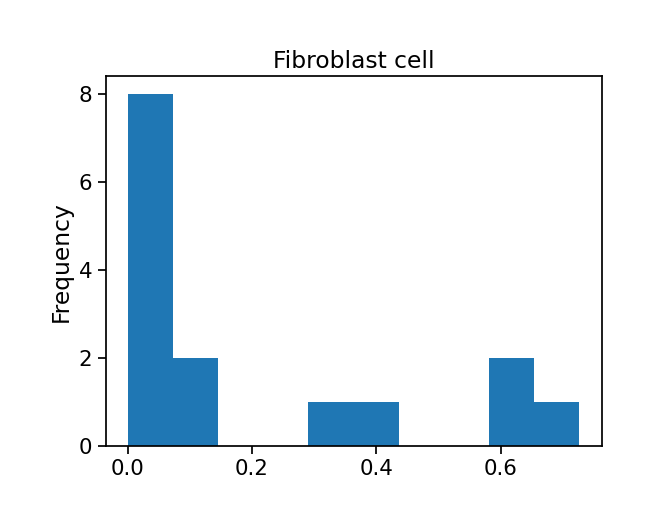

In [86]:
sub_n2['Fibroblast cell'].plot(kind='hist', title='Fibroblast cell')


<Axes: title={'center': 'Acinar cell'}, ylabel='Frequency'>

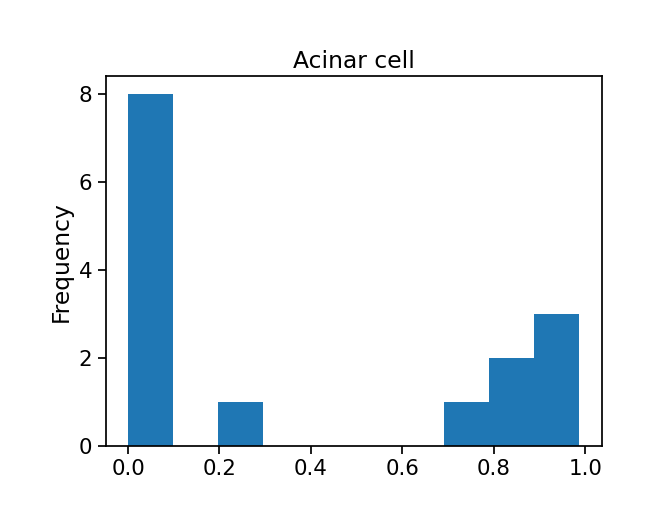

In [87]:
sub_n2['Acinar cell'].plot(kind='hist', title='Acinar cell')


In [88]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

<Axes: title={'center': 'Ductal cell type 1'}, ylabel='Frequency'>

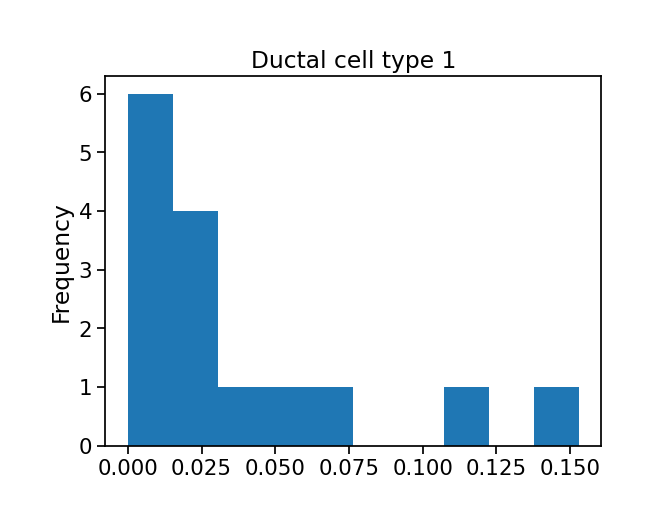

In [89]:
sub_n2['Ductal cell type 1'].plot(kind='hist', title='Ductal cell type 1')

<Axes: title={'center': 'Ductal cell type 2'}, ylabel='Frequency'>

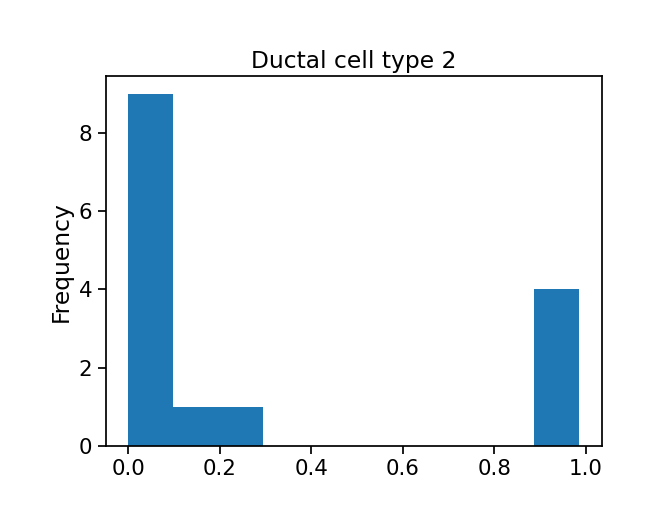

In [90]:
sub_n2['Ductal cell type 2'].plot(kind='hist', title='Ductal cell type 2')

In [91]:
cols = ['Fibroblast cell', 'Acinar cell']
sub_n2[cols]

,Fibroblast cell,Acinar cell
N-C3L-04072,1.334e-01,7.297e-01
N-C3L-00589,1.205e-03,3.736e-154
N-C3L-03123,7.766e-03,9.845e-01
N-C3L-04080,6.720e-04,4.473e-189
N-C3L-00640,3.754e-01,0.000e+00
N-C3N-01719,6.235e-01,0.000e+00
N-C3L-07033,1.122e-02,9.605e-01
N-C3L-00819,3.540e-01,2.952e-01
N-C3L-01689,1.879e-03,8.252e-201
N-C3N-01899,7.255e-01,0.000e+00


In [92]:
cols = ['Fibroblast cell', 'Acinar cell']

keep1 = sub_n2['Fibroblast cell'] > 0.001
keep2 = sub_n2['Acinar cell'] > 0.001

sub_n2[keep1 & keep2][cols]

,Fibroblast cell,Acinar cell
N-C3L-04072,0.133,0.730
N-C3L-03123,0.008,0.985
N-C3L-07033,0.011,0.960
N-C3L-00819,0.354,0.295
N-C3N-00517,0.074,0.876
N-C3N-02765,0.005,0.986
N-C3L-07037,0.043,0.844
N-TCGA-H6-8124,0.581,0.034


In [93]:
sel = sub_n2[keep1 & keep2].index
# does psi_fibro actually vary across these, or is it the reference profile?
P = psi_n_fibro[sel].dropna(axis=1, how='all')
C = np.log1p(P).corr(method='spearman')
print(C.round(3).to_string())

                N-C3L-04072  N-C3L-03123  N-C3L-07033  N-C3L-00819  N-C3N-00517  N-C3N-02765  N-C3L-07037  N-TCGA-H6-8124
N-C3L-04072           1.000        0.938        0.936        0.980        0.970        0.917        0.947           0.920
N-C3L-03123           0.938        1.000        0.971        0.933        0.951        0.967        0.953           0.853
N-C3L-07033           0.936        0.971        1.000        0.931        0.945        0.957        0.961           0.844
N-C3L-00819           0.980        0.933        0.931        1.000        0.970        0.919        0.947           0.934
N-C3N-00517           0.970        0.951        0.945        0.970        1.000        0.932        0.951           0.911
N-C3N-02765           0.917        0.967        0.957        0.919        0.932        1.000        0.939           0.843
N-C3L-07037           0.947        0.953        0.961        0.947        0.951        0.939        1.000           0.868
N-TCGA-H6-8124        0.

These correlations don't show the pattern I predicted, and they're better than I expected.

I said the low-θ samples would cluster tightly on the prior. They don't. The three lowest-θ samples — C3L-03123 (0.008), C3N-02765 (0.005), C3L-07033 (0.011) — correlate with each other at 0.957–0.971, which is high but *not* the >0.99 you'd see if all three had collapsed onto the same reference profile. There's genuine sample-specific signal in them.

And the structure runs the other way from what I claimed. Sort by correlation with TCGA-H6-8124 (θ_fib = 0.581, the best-determined sample):

| | θ_fib | r to H6-8124 |
|---|---|---|
| C3L-00819 | 0.354 | 0.934 |
| C3L-04072 | 0.133 | 0.920 |
| C3N-00517 | 0.074 | 0.911 |
| C3L-07037 | 0.043 | 0.868 |
| C3L-03123 | 0.008 | 0.853 |
| C3L-07033 | 0.011 | 0.844 |
| C3N-02765 | 0.005 | 0.843 |

Monotone in θ, almost perfectly. Similarity to the well-determined sample **increases** with θ — the opposite of prior domination, where the low-θ samples would have been mutually identical and jointly distinct from H6-8124.

So there are two coherent groups rather than one signal plus noise: {H6-8124, C3L-00819, C3L-04072} at higher θ, and {C3L-03123, C3L-07033, C3N-02765} at very low θ, with C3N-00517 and C3L-07037 between. That's consistent with a θ-dependent gradient in the profile — some shrinkage toward the reference at low θ, but partial rather than total.

Quantify it directly:

```python
import numpy as np
from scipy.stats import spearmanr
th_f = sub_n2.loc[sel, 'Fibroblast cell']
r_anchor = C['N-TCGA-H6-8124'].drop('N-TCGA-H6-8124')
print(spearmanr(th_f.drop('N-TCGA-H6-8124'), r_anchor))

# and against the actual reference profile, which is the decisive test
ref_fib = ref_new.loc['Fibroblast cell']            # ENSG-indexed
common = P.index.intersection(ref_fib.index)
r_ref = np.log1p(P.loc[common]).corrwith(np.log1p(ref_fib.loc[common]), method='spearman')
print(r_ref.to_frame('r_to_reference').join(th_f).sort_values('Fibroblast cell').to_string())
```

That second block settles it. If `r_to_reference` rises as θ falls, the low-θ profiles are being pulled toward the prior and the amount is measurable. If it's flat, they're carrying real sample-specific information and my concern was unfounded.

**Either way, my "effective n is closer to 3" claim was wrong** — there's more independent variation across these eight than that implied. Whether n=8 supports limma still depends on the `r_to_reference` result, but the correlation matrix alone doesn't rule it out the way I said it would.

In [94]:

th_f = sub_n2.loc[sel, 'Fibroblast cell']
r_anchor = C['N-TCGA-H6-8124'].drop('N-TCGA-H6-8124')
print(spearmanr(th_f.drop('N-TCGA-H6-8124'), r_anchor))

# and against the actual reference profile, which is the decisive test
ref_fib = ref_new.loc['Fibroblast cell']            # ENSG-indexed
common = P.index.intersection(ref_fib.index)
r_ref = np.log1p(P.loc[common]).corrwith(np.log1p(ref_fib.loc[common]), method='spearman')
print(r_ref.to_frame('r_to_reference').join(th_f).sort_values('Fibroblast cell').to_string())

SignificanceResult(statistic=0.9642857142857145, pvalue=0.00045414916919416935)
                r_to_reference  Fibroblast cell
N-C3N-02765              0.760            0.005
N-C3L-03123              0.764            0.008
N-C3L-07033              0.765            0.011
N-C3L-07037              0.787            0.043
N-C3N-00517              0.810            0.074
N-C3L-04072              0.817            0.133
N-C3L-00819              0.824            0.354
N-TCGA-H6-8124           0.851            0.581


This refutes my prediction cleanly, and in the interesting direction.

I said similarity to the reference would **rise** as θ falls — that's what prior domination means. It does the opposite: `r_to_reference` is perfectly monotone *increasing* in θ, from 0.760 at θ=0.005 to 0.851 at θ=0.581. The best-determined sample is the one that looks most like the prior; the worst-determined ones look least like it.

That rules out shrinkage-toward-reference as the mechanism here. Whatever is happening at low θ, it's pushing profiles *away* from the reference, not toward it.

The likely explanation is division noise. `state_expression` divides Z by θ, so at θ=0.005 you're multiplying by 200, and the Gibbs sampler's assignment noise gets amplified by the same factor. The profile becomes noisy rather than prior-like, and noise lowers correlation with everything — including the reference. Consistent with the anchor correlations too: 0.843 to H6-8124 versus 0.760 to the reference, both depressed at low θ.

Distinguishing noise from real biology is one line — noise is symmetric, shrinkage is directional:

```python
L = np.log1p(P.loc[common])
lr = ref_fib.loc[common].pipe(np.log1p)
print(L.std().to_frame('sd').join(th_f).sort_values('Fibroblast cell').to_string())
# and the slope of each sample against the reference
print(L.apply(lambda c: np.polyfit(lr, c, 1)[0]).to_frame('slope').join(th_f).to_string())
```

If SD rises as θ falls, it's amplified noise. If SD is flat and only the correlation drops, something else is going on.

The band is narrow either way — 0.760 to 0.851 across a hundredfold θ range. So the degradation is real but gradual, not a cliff. That argues these eight samples do carry sample-specific information rather than being eight copies of the prior, which is what I claimed two messages ago and was wrong about.

Practical consequence: if the low-θ samples are noisy rather than biased, limma is better suited than I said. Noise inflates within-group variance, which makes the test **conservative** — you lose power, you don't gain false positives. That's the opposite of the anticonservative failure I warned about. The caveat that survives is that the noise is heteroscedastic across samples, and limma's `lmFit` weights all samples equally, so `arrayWeights()` would be the right addition:

```r
w <- arrayWeights(E, design)
fit <- eBayes(lmFit(E, design, weights = w), trend = TRUE, robust = TRUE)
```

That downweights the low-θ normals automatically rather than requiring you to pick a cutoff. Worth adding to `calc_degs_v2.R` before the real run.

In [98]:
# del(CALC_DEGS_PSI)

In [99]:
import importlib, filter_and_lfc

importlib.reload(filter_and_lfc)
print(filter_and_lfc.__version__)

0.1.0


In [100]:
from libs.calc_degs_psi_lib import CALC_DEGS_PSI
from filter_and_lfc import run_lfc, theta_report

In [101]:
rscript_name= str(ROOT_SRC / "libs/calc_degs_v2.R")
print(rscript_name)

calc = CALC_DEGS_PSI(root_src=ROOT_SRC, run_conda=True, rscript_name=rscript_name)

/home/flavio/uv/perturb_agent/src/libs/calc_degs_v2.R


In [102]:
import libs.calc_degs_psi_lib
print(libs.calc_degs_psi_lib.__file__)

import inspect
src = inspect.getsource(libs.calc_degs_psi_lib.CALC_DEGS_PSI.run_limma)
print("array_weights" in src)
print([l for l in src.splitlines() if "array_weights" in l or "normalize" in l][:5])

/home/flavio/uv/perturb_agent/src/libs/calc_degs_psi_lib.py
True
['        normalize: Literal["none", "quantile", "scale"] = "none",', '        array_weights: bool = False,', '                "--normalize", normalize,', '            if array_weights:']


In [103]:
import inspect
print(inspect.signature(libs.calc_degs_psi_lib.CALC_DEGS_PSI.run_limma))

(self, psi_tumor: 'pd.DataFrame', psi_normal: 'pd.DataFrame', mode: "Literal['limma_trend', 'limma_voom']" = 'limma_trend', pairs: 'Mapping[str, str] | None' = None, sample_meta: 'pd.DataFrame | None' = None, covariates: 'Sequence[str] | None' = None, pair_col: 'str | None' = None, already_log: 'bool' = False, normalize: "Literal['none', 'quantile', 'scale']" = 'none', array_weights: 'bool' = False, min_prop_detected: 'float' = 0.2, prior_count: 'float' = 0.5, merge_how: "Literal['inner', 'outer']" = 'inner', conda_env: 'str' = 'renv', keep_temp: 'bool' = False, verbose: 'bool' = True) -> 'pd.DataFrame'


In [105]:
import libs.calc_degs_psi_lib
print(libs.calc_degs_psi_lib.__file__)

import inspect
src = inspect.getsource(libs.calc_degs_psi_lib.CALC_DEGS_PSI.run_limma)
print("array_weights" in src)
print([l for l in src.splitlines() if "array_weights" in l or "normalize" in l][:5])

/home/flavio/uv/perturb_agent/src/libs/calc_degs_psi_lib.py
True
['        normalize: Literal["none", "quantile", "scale"] = "none",', '        array_weights: bool = False,', '                "--normalize", normalize,', '            if array_weights:']


In [107]:
df_fib, info = run_lfc(
    calc, psi_t_fibro, psi_n_fibro, res.theta,
    compartment      = "Fibroblast cell",
    min_theta_normal = 0.001,
    require_states   = {"Acinar cell": 0.001},
    max_state        = {"Ductal cell type 2": 0.30},
    cohort           = "C3",            # see note below
    array_weights    = True,
    min_prop_detected= 0.50,
)
print(info)


=== Fibroblast cell ===
 tumour arm:
  kept 122/131
    -  1  no theta (all-NaN row)
    -  8  Fibroblast cell <= 0.01
    theta[Fibroblast cell] range: 0.01174 .. 0.9318
 normal arm:
  kept 8/22
    -  7  no theta (all-NaN row)
    -  1  Fibroblast cell <= 0.001
    -  6  Acinar cell <= 0.001
    theta[Fibroblast cell] range: 0.004686 .. 0.5815
 restricted to C3: 49 tumour / 7 normal
  theta spans 76x across normals -- array_weights strongly recommended
  normal n=  7  median=14.8  zero_frac=0.029
  tumor  n= 49  median=16.18  zero_frac=0.012
[calc_degs] method=limma_trend  genes=17510  normal=7  tumor=49
[calc_degs] design: ~condition
[calc_degs] array weights: min=0.380 median=1.060 max=2.335
[calc_degs] five lowest-weight samples:
         sample    weight
 T__T-C3L-03639 0.3803910
 T__T-C3L-01032 0.3875009
 T__T-C3L-04072 0.4026906
 T__T-C3N-04284 0.4831683
 N__N-C3N-02765 0.4984002
[calc_degs] wrote 17510 rows (padj<0.05: 7075)
  n=49T / 7N fdr<0.05: 7075
{'compartment': 'Fibrob

In [111]:
df_fib2 = df_fib[ (df_fib.fdr < 0.05) & (df_fib.abs_lfc >= 1)]

gm = prism.load_gene_map("geneid")
id2sym = gm["symbol"].astype(str).to_dict()

df_fib2 = df_fib2.copy()
df_fib2.insert(1, "symbol", df_fib2["geneid"].map(id2sym))

print(df_fib2.shape)
df_fib2

(1797, 10)


,geneid,symbol,lfc,AveExpr,statistic,pvalue,fdr,B,method,abs_lfc
0,ENSG00000178922,HYI,-5.372,-0.324,-107.460,4.423e-68,7.746e-64,130.165,limma_trend_aw,5.372
1,ENSG00000173349,SFT2D3,-4.060,-0.492,-72.937,1.865e-58,1.633e-54,115.952,limma_trend_aw,4.060
2,ENSG00000136305,CIDEB,-3.729,-0.536,-65.996,5.545e-56,3.236e-52,111.691,limma_trend_aw,3.729
3,ENSG00000148671,ADIRF,-5.385,-0.315,-49.853,4.521e-49,1.979e-45,98.726,limma_trend_aw,5.385
4,ENSG00000142684,ZNF593,-3.197,-0.597,-42.787,2.331e-45,8.162e-42,91.249,limma_trend_aw,3.197
...,...,...,...,...,...,...,...,...,...,...
6983,ENSG00000171951,SCG2,-1.393,6.197,-2.411,1.913e-02,4.797e-02,-4.524,limma_trend_aw,1.393
7037,ENSG00000137868,STRA6,1.107,5.135,2.397,1.979e-02,4.923e-02,-4.554,limma_trend_aw,1.107
7041,ENSG00000152578,GRIA4,-1.304,2.540,-2.396,1.985e-02,4.935e-02,-4.557,limma_trend_aw,1.304
7046,ENSG00000260230,FRRS1L,-1.216,2.674,-2.395,1.990e-02,4.945e-02,-4.559,limma_trend_aw,1.216


In [114]:
from libs.Basic import write_txt

write_txt( '\n'.join(df_fib2.symbol), "df_fib2.txt")   

True

### Why Neuro in fibro?

In [131]:

neuro = ["NRXN1","NLGN1","SLIT2","SLIT3","ROBO1","ROBO2","SEMA3A","SEMA3C",
         "EPHA4","EPHB2","NCAM1","L1CAM","GFRA1","NGFR","S100B","PLP1","MPZ","SOX10"]
df_fib2[df_fib2.symbol.isin(neuro)][["geneid", "symbol","lfc","AveExpr","fdr"]]


,geneid,symbol,lfc,AveExpr,fdr
603,ENSG00000123560,PLP1,-3.177,2.743,2.214e-06
665,ENSG00000145147,SLIT2,-2.126,7.397,3.915e-06
786,ENSG00000184347,SLIT3,-2.527,6.036,9.181e-06
1153,ENSG00000100146,SOX10,-1.899,1.390,5.126e-05
1937,ENSG00000179915,NRXN1,-3.283,3.917,3.877e-04
2080,ENSG00000198910,L1CAM,-2.846,1.477,5.023e-04
2445,ENSG00000064300,NGFR,-2.575,3.907,8.847e-04
2552,ENSG00000151892,GFRA1,-2.211,4.945,1.032e-03
4907,ENSG00000169760,NLGN1,-1.280,2.575,1.241e-02
5412,ENSG00000116106,EPHA4,1.302,4.556,1.831e-02


### Acinar

In [116]:
df_aci, info = run_lfc(
    calc, psi_t_acinar, psi_n_acinar, res.theta,
    compartment      = "Acinar cell",
    min_theta_normal = 0.001,
    require_states   = {"Fibroblast cell": 0.001},   # not Acinar -- it IS the compartment
    max_state        = {"Ductal cell type 2": 0.30},
    cohort           = "C3",
    array_weights    = True,
    min_prop_detected= 0.50,
)
print(info)


=== Acinar cell ===
 tumour arm:
  kept 50/131
    -  1  no theta (all-NaN row)
    - 80  Acinar cell <= 0.01
    theta[Acinar cell] range: 0.01093 .. 0.9911
 normal arm:
  kept 8/22
    -  7  no theta (all-NaN row)
    -  7  Acinar cell <= 0.001
    theta[Acinar cell] range: 0.03388 .. 0.9861
 restricted to C3: 22 tumour / 7 normal
  normal n=  7  median=11.83  zero_frac=0.029
  tumor  n= 22  median=13.68  zero_frac=0.010
[calc_degs] method=limma_trend  genes=17503  normal=7  tumor=22
[calc_degs] design: ~condition
[calc_degs] array weights: min=0.231 median=1.010 max=2.151
[calc_degs] five lowest-weight samples:
         sample    weight
 N__N-C3N-02765 0.2310047
 N__N-C3L-03123 0.4226837
 T__T-C3N-04284 0.4947705
 N__N-C3L-07033 0.5792086
 N__N-C3L-00819 0.6473532
[calc_degs] wrote 17503 rows (padj<0.05: 3045)
  n=22T / 7N fdr<0.05: 3045
{'compartment': 'Acinar cell', 'n_tumor': 22, 'n_normal': 7, 'theta_normal': {'count': 7.0, 'mean': 0.810882396630679, 'std': 0.24534879176900315,

In [117]:
df_aci2 = df_aci[ (df_aci.fdr < 0.05) & (df_aci.abs_lfc >= 1)]

gm = prism.load_gene_map("geneid")
id2sym = gm["symbol"].astype(str).to_dict()

df_aci2 = df_aci2.copy()
df_aci2.insert(1, "symbol", df_aci2["geneid"].map(id2sym))

print(df_aci2.shape)
df_aci2

(698, 10)


,geneid,symbol,lfc,AveExpr,statistic,pvalue,fdr,B,method,abs_lfc
0,ENSG00000178922,HYI,-5.981,0.434,-97.614,1.338e-36,2.341e-32,62.887,limma_trend_aw,5.981
1,ENSG00000173349,SFT2D3,-4.455,0.063,-69.556,1.689e-32,1.478e-28,58.216,limma_trend_aw,4.455
2,ENSG00000136305,CIDEB,-4.200,-0.019,-54.225,1.550e-29,9.045e-26,53.871,limma_trend_aw,4.200
3,ENSG00000166333,ILK,-4.785,2.395,-36.400,7.816e-25,2.874e-21,45.468,limma_trend_aw,4.785
4,ENSG00000168282,MGAT2,-5.307,0.959,-36.334,8.211e-25,2.874e-21,45.427,limma_trend_aw,5.307
...,...,...,...,...,...,...,...,...,...,...
2989,ENSG00000212128,TAS2R13,-1.029,-0.735,-2.844,8.294e-03,4.855e-02,-3.638,limma_trend_aw,1.029
2995,ENSG00000125848,FLRT3,1.073,4.544,2.843,8.331e-03,4.867e-02,-3.642,limma_trend_aw,1.073
3016,ENSG00000131746,TNS4,1.915,1.686,2.835,8.487e-03,4.923e-02,-3.659,limma_trend_aw,1.915
3025,ENSG00000153823,PID1,-1.201,2.263,-2.832,8.551e-03,4.946e-02,-3.666,limma_trend_aw,1.201


In [118]:
write_txt( '\n'.join(df_aci2.symbol), "df_aci2.txt")   

True

In [124]:
core = ["PRSS1","CPA1","CPB1","CELA3A","CTRB1","PNLIP","CLPS"]
df_aci2[df_aci2.symbol.isin(core)][["geneid", "symbol","lfc","AveExpr","fdr"]]

,geneid,symbol,lfc,AveExpr,fdr
1255,ENSG00000137392,CLPS,-1.46,11.742,0.012


In [122]:
df_aci = df_aci.copy()
df_aci.insert(1, "symbol", df_aci["geneid"].map(id2sym))

In [123]:
core = ["PRSS1","CPA1","CPB1","CELA3A","CTRB1","PNLIP","CLPS"]
df_aci[df_aci.symbol.isin(core)][["geneid", "symbol","lfc","AveExpr","fdr"]]

,geneid,symbol,lfc,AveExpr,fdr
1255,ENSG00000137392,CLPS,-1.460,11.742,0.012
3757,ENSG00000204983,PRSS1,-0.645,14.965,0.070
5624,ENSG00000091704,CPA1,-0.496,14.852,0.140
5676,ENSG00000175535,PNLIP,-0.744,15.365,0.142
7592,ENSG00000168925,CTRB1,-0.377,13.032,0.249
9199,ENSG00000153002,CPB1,-0.205,15.708,0.363
10004,ENSG00000142789,CELA3A,0.411,9.263,0.437


In [125]:
from scipy.stats import wilcoxon

gm = prism.load_gene_map("geneid")
sym2id = {s: i for i, s in gm["symbol"].astype(str).items()}

core_ids = [sym2id[g] for g in core if g in sym2id]
sub = df_aci[df_aci.geneid.isin(core_ids)]
print(wilcoxon(sub.lfc))                       # panel shifted from zero?
print("all genes median lfc:", df_aci.lfc.median().round(3))
print("core panel median   :", sub.lfc.median().round(3))

WilcoxonResult(statistic=3.0, pvalue=0.078125)
all genes median lfc: 0.141
core panel median   : -0.496


In [126]:
adm = ["SOX9","KRT19","ONECUT1","HNF1B"]
df_aci[df_aci.symbol.isin(adm)][["geneid", "symbol","lfc","AveExpr","fdr"]]

,geneid,symbol,lfc,AveExpr,fdr
4839,ENSG00000125398,SOX9,0.656,6.460,0.108
6583,ENSG00000171345,KRT19,0.694,7.098,0.191
10850,ENSG00000169856,ONECUT1,-0.303,6.208,0.513
15359,ENSG00000275410,HNF1B,0.031,5.821,1.000


In [128]:
genes = []

for key, g in ACINAR_CORE.items():
    genes += g

genes = np.unique(genes)
len(genes), genes

(44,
 array(['AMY1A', 'AMY2A', 'AMY2B', 'AQP12A', 'AQP12B', 'AQP8', 'BHLHA15',
        'CEL', 'CELA1', 'CELA2A', 'CELA2B', 'CELA3A', 'CELA3B', 'CLPS',
        'CPA1', 'CPA2', 'CPB1', 'CPO', 'CTRB1', 'CTRB2', 'CTRC', 'CTRL',
        'CUZD1', 'DPEP1', 'ERP27', 'GATA4', 'GP2', 'KLK1', 'MYRF', 'NR5A2',
        'PDIA2', 'PLA2G1B', 'PNLIP', 'PNLIPRP1', 'PNLIPRP2', 'PRSS1',
        'PRSS2', 'PRSS3', 'PTF1A', 'RBPJL', 'SEC11C', 'SERPINI2', 'SYCN',
        'ZG16'], dtype='<U8'))

In [133]:
df2 = df_aci[df_aci.symbol.isin(genes)][["geneid", "symbol","lfc","AveExpr","fdr"]]
print(df2.shape)

df2

(39, 5)


,geneid,symbol,lfc,AveExpr,fdr
285,ENSG00000141086,CTRL,-2.052e+00,-0.300,6.284e-06
872,ENSG00000124232,RBPJL,-1.306e+00,6.915,5.531e-03
1255,ENSG00000137392,CLPS,-1.460e+00,11.742,1.183e-02
1500,ENSG00000170835,CEL,-7.526e-01,13.680,1.689e-02
1602,ENSG00000139055,ERP27,-7.291e-01,8.700,1.880e-02
2429,ENSG00000184945,AQP12A,-1.595e+00,2.363,3.528e-02
3693,ENSG00000219073,CELA3B,-7.145e-01,10.498,6.748e-02
3757,ENSG00000204983,PRSS1,-6.451e-01,14.965,6.963e-02
3761,ENSG00000215704,CELA2B,-8.205e-01,10.224,6.970e-02
4150,ENSG00000185176,AQP12B,-1.335e+00,3.662,8.321e-02


In [137]:
# gene_subset = prism.select_genes(ref_new)

dfm = df_fib.merge(df_aci, on="geneid", suffixes=("_fib","_aci"))
print("lfc correlation across compartments:", dfm.lfc_fib.corr(dfm.lfc_aci).round(3))

dfm

lfc correlation across compartments: 0.773


,geneid,lfc_fib,AveExpr_fib,statistic_fib,pvalue_fib,fdr_fib,B_fib,method_fib,abs_lfc_fib,symbol,lfc_aci,AveExpr_aci,statistic_aci,pvalue_aci,fdr_aci,B_aci,method_aci,abs_lfc_aci
0,ENSG00000178922,-5.372e+00,-0.324,-1.075e+02,4.423e-68,7.746e-64,130.165,limma_trend_aw,5.372e+00,HYI,-5.981e+00,0.434,-9.761e+01,1.338e-36,2.341e-32,62.887,limma_trend_aw,5.981e+00
1,ENSG00000173349,-4.060e+00,-0.492,-7.294e+01,1.865e-58,1.633e-54,115.952,limma_trend_aw,4.060e+00,SFT2D3,-4.455e+00,0.063,-6.956e+01,1.689e-32,1.478e-28,58.216,limma_trend_aw,4.455e+00
2,ENSG00000136305,-3.729e+00,-0.536,-6.600e+01,5.545e-56,3.236e-52,111.691,limma_trend_aw,3.729e+00,CIDEB,-4.200e+00,-0.019,-5.423e+01,1.550e-29,9.045e-26,53.871,limma_trend_aw,4.200e+00
3,ENSG00000148671,-5.385e+00,-0.315,-4.985e+01,4.521e-49,1.979e-45,98.726,limma_trend_aw,5.385e+00,ADIRF,-4.862e+00,0.216,-3.190e+01,2.727e-23,5.966e-20,42.394,limma_trend_aw,4.862e+00
4,ENSG00000142684,-3.197e+00,-0.597,-4.279e+01,2.331e-45,8.162e-42,91.249,limma_trend_aw,3.197e+00,ZNF593,-4.015e+00,-0.059,-3.515e+01,2.012e-24,5.870e-21,44.663,limma_trend_aw,4.015e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17490,ENSG00000136327,2.011e-10,-1.000,6.560e-09,1.000e+00,1.000e+00,-7.328,limma_trend_aw,2.011e-10,NKX2-8,4.245e-02,-0.888,5.008e-01,6.205e-01,8.050e-01,-7.166,limma_trend_aw,4.245e-02
17491,ENSG00000122859,1.435e-10,-1.000,4.680e-09,1.000e+00,1.000e+00,-7.328,limma_trend_aw,1.435e-10,NEUROG3,2.585e-09,-1.000,5.117e-07,1.000e+00,1.000e+00,-7.294,limma_trend_aw,2.585e-09
17492,ENSG00000124233,-1.256e-10,-1.000,-4.096e-09,1.000e+00,1.000e+00,-7.328,limma_trend_aw,1.256e-10,SEMG1,1.765e-09,-1.000,3.493e-07,1.000e+00,1.000e+00,-7.294,limma_trend_aw,1.765e-09
17493,ENSG00000261587,1.248e-10,-1.000,4.073e-09,1.000e+00,1.000e+00,-7.328,limma_trend_aw,1.248e-10,TMEM249,6.140e-02,-0.919,9.558e-01,3.475e-01,5.440e-01,-6.831,limma_trend_aw,6.140e-02


In [138]:
fitted = set(gene_subset)
dfm["is_fitted"] = dfm.geneid.isin(fitted)
print(dfm.groupby("is_fitted")[["lfc_fib","lfc_aci"]].corr().iloc[0::2,1].round(3))

is_fitted         
False      lfc_fib    0.767
True       lfc_fib    0.806
Name: lfc_aci, dtype: float64


That refutes my hypothesis, and cleanly. Fitted genes correlate **0.806** across compartments, projected genes **0.767** — fitted is *higher*. So the shared signal isn't a `full_Z` projection artifact, and restricting to `gene_subset` would not fix it.

I was wrong about the mechanism. The correct reading is simpler and worse: **the two compartments' tumour-vs-normal contrasts are ~80% the same contrast, everywhere.** That's consistent with the `zm` vs `zf` r ≈ 0.93 we measured much earlier — the compartments share most of their variance regardless of which genes you use, and a differential test between arms inherits that.

So CPO significant in fibroblast, dead in acinar, isn't leakage — it's the bulk contrast passing through a compartment where that gene's psi sits at the zero boundary and truncation amplifies it. `AveExpr` −1.0 exactly, LFC −1.7e-07 in acinar: that gene has no data in either compartment.

Two consequences.

**Compartment-specific DEG lists aren't supportable from this design.** Neither restricting genes nor changing compartments separates them. The honest statement is that per-compartment limma on deconvolved psi returns a largely shared tumour-vs-normal signal, and the acinar-core-in-fibroblast result is the ground-truth demonstration.

**Which is exactly why the program-score route worked.** Contrasts within a compartment (basal−classical, prolif vs iCAF across compartments) cancel the shared component; raw per-gene arms do not. That's now demonstrated three ways — the r=0.93 measurement, the PCA contrast/sum decomposition, and this.

Worth one check to see whether anything survives the shared component:

```python
m["delta"] = m.lfc_fib - m.lfc_aci
m["is_fitted"] = m.geneid.isin(fitted)
top = m.reindex(m.delta.abs().sort_values(ascending=False).index).head(30)
top[["geneid","lfc_fib","lfc_aci","delta","is_fitted"]]
```

Genes with large |delta| are where the compartments genuinely diverge. If those are enriched for fitted genes and for markers of the respective compartments, that's the compartment-specific residual — and it's the only part of these DEG lists worth interpreting.

In [ ]:
dfm["delta"] = dfm.lfc_fib - dfm.lfc_aci
dfm["is_fitted"] = dfm.geneid.isin(fitted)
top = dfm.reindex(dfm.delta.abs().sort_values(ascending=True).index)
top = [(top[top.lfc_fib.abs() > 0.001]) or (top[top.lfc_aci.abs() > 0.001])]

cols = ["geneid", "symbol", "lfc_fib","lfc_aci","delta","is_fitted"]


top[top.is_fitted == True][cols]

,geneid,symbol,lfc_fib,lfc_aci,delta,is_fitted
17434,ENSG00000167634,NLRP7,-2.606e-09,-4.395e-09,1.789e-09,True
17467,ENSG00000111536,IL26,-9.643e-10,3.265e-09,-4.229e-09,True


In [145]:
top[top.is_fitted == False][cols]

,geneid,symbol,lfc_fib,lfc_aci,delta,is_fitted
17408,ENSG00000179141,MTUS2-AS1,4.637e-09,4.603e-09,3.423e-11,False
17488,ENSG00000140465,CYP1A1,2.903e-10,9.698e-10,-6.795e-10,False
17480,ENSG00000268223,ARL14EPL,-6.096e-10,3.733e-10,-9.828e-10,False
17364,ENSG00000100012,SEC14L3,1.118e-08,1.229e-08,-1.111e-09,False
17406,ENSG00000168314,MOBP,-4.865e-09,-6.072e-09,1.206e-09,False
17407,ENSG00000136688,IL36G,4.860e-09,6.104e-09,-1.244e-09,False
17485,ENSG00000206069,TMEM211,-4.234e-10,-1.771e-09,1.348e-09,False
17492,ENSG00000124233,SEMG1,-1.256e-10,1.765e-09,-1.890e-09,False
17487,ENSG00000226097,AC099342.1,4.061e-10,2.606e-09,-2.200e-09,False
17451,ENSG00000181009,OR52N5,1.851e-09,4.053e-09,-2.201e-09,False


In [127]:
# --------------------------------------------------------------------------- #
# ACINAR
# --------------------------------------------------------------------------- #

ACINAR_CORE = {
    # serine proteases / zymogens -- the highest-abundance transcripts in pancreas
    "proteases": [
        "PRSS1", "PRSS2", "PRSS3", "CTRB1", "CTRB2", "CTRC", "CTRL",
        "CELA2A", "CELA2B", "CELA3A", "CELA3B", "CELA1",
        "CPA1", "CPA2", "CPB1", "CPO",
    ],
    # lipases, amylases, other digestive enzymes
    "lipase_amylase": [
        "PNLIP", "PNLIPRP1", "PNLIPRP2", "CLPS", "CEL", "PLA2G1B",
        "AMY2A", "AMY2B", "AMY1A",
    ],
    # zymogen granule / regulated secretory machinery
    "secretory_machinery": [
        "SYCN", "GP2", "CUZD1", "ZG16", "PDIA2", "ERP27", "SEC11C",
        "AQP8", "AQP12A", "AQP12B", "SERPINI2", "KLK1", "DPEP1",
    ],
    # acinar identity transcription factors
    "identity_tf": [
        "PTF1A", "RBPJL", "BHLHA15", "NR5A2", "GATA4", "MYRF",
    ],
}

ACINAR_FLAGGED = {
    "regenerating_adm": ["REG1A", "REG1B", "REG3A", "REG3G", "REG4"],
    "shared_epithelial": ["SPINK1", "RNASE1", "MUC1", "TFF1", "TFF2", "LGALS4"],
    "stress_metaplasia": ["ONECUT1", "SOX9", "KRT19", "CFTR"],
}

# --------------------------------------------------------------------------- #
# FIBROBLAST / STELLATE
# --------------------------------------------------------------------------- #

FIBROBLAST_CORE = {
    "collagens": [
        "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL5A2", "COL5A3",
        "COL6A1", "COL6A2", "COL6A3", "COL8A1", "COL10A1", "COL11A1",
        "COL12A1", "COL14A1", "COL15A1", "COL16A1",
    ],
    "ecm_glycoprotein": [
        "FBN1", "FBLN1", "FBLN2", "FBLN5", "THBS2", "TNC", "POSTN",
        "VCAN", "LUM", "DCN", "FMOD", "OGN", "ASPN", "PRELP", "MGP",
        "ELN", "EMILIN1", "LTBP1", "LTBP2", "MFAP2", "MFAP4", "MFAP5",
        "NID2", "SPON1", "ISLR",
    ],
    "remodeling_crosslink": [
        "LOX", "LOXL1", "LOXL2", "PLOD1", "PLOD2", "SERPINH1",
        "MMP2", "MMP11", "MMP14", "MMP23B", "TIMP2", "TIMP3",
        "ADAM12", "ADAMTS2", "ADAMTS12", "SULF1", "PCOLCE",
    ],
    "identity_receptor": [
        "PDGFRA", "PDGFRB", "FAP", "THY1", "CD248", "ITGA11", "DDR2",
        "LRRC15", "ANTXR1", "GLI1", "PDPN",
    ],
    "identity_tf": [
        "TWIST1", "TWIST2", "PRRX1", "SNAI2", "FOXF1", "FOXF2", "EBF1",
    ],
    "matricellular": [
        "CCN1", "CCN2", "CCN3", "CCN5", "SPARCL1",
    ],
}

FIBROBLAST_FLAGGED = {
    "pericyte_smc_overlap": ["ACTA2", "TAGLN", "MYL9", "CNN1", "TPM1",
                             "TPM2", "PDLIM3", "RGS5", "NOTCH3", "MYH11"],
    "broadly_expressed":   ["VIM", "SPARC", "FN1", "THBS1", "TIMP1", "S100A4"],
    "immune_shared":       ["IL6", "CXCL1", "CXCL2", "CXCL12", "CCL2",
                            "C3", "C7", "CFD", "C1S", "C1R", "LIF", "IL11",
                            "HAS1", "HAS2", "PTGDS"],
    "quiescent_stellate":  ["LRAT", "DES", "NGFR", "CYGB", "RELN", "PDZRN4"],
}

RISK = {
    # ---- acinar ----
    "regenerating_adm": (
        "REG family is induced by inflammation and acinar-to-ductal metaplasia. "
        "In adjacent-normal PDAC tissue (pancreatitis, ADM) these are up for reasons "
        "unrelated to acinar abundance, so they corrupt the normal arm of the contrast."
    ),
    "shared_epithelial": (
        "Expressed by ductal and malignant cells. SPINK1 in particular is elevated in "
        "PDAC -- including it puts a tumour-up gene inside a compartment that is "
        "tumour-down, which inverts the contrast."
    ),
    "stress_metaplasia": (
        "Ductal-programme genes switched on during ADM. High values mean acinar cells "
        "are becoming ductal, i.e. the compartment identity itself is unstable -- "
        "which breaks the same-compartment-two-states assumption."
    ),
    # ---- fibroblast ----
    "pericyte_smc_overlap": (
        "Shared with pericytes and vascular smooth muscle. Direct attribution risk "
        "against the endothelial compartment; RGS5 is a pericyte marker first. "
        "Any fibroblast<->endothelial correlation built on these is suspect."
    ),
    "broadly_expressed": (
        "Expressed at meaningful levels by most cell types including malignant. "
        "Low compartment share, so BayesPrism's split is prior-dominated -- exactly "
        "the genes that manufacture cross-compartment coupling."
    ),
    "immune_shared": (
        "The iCAF programme proper, but overlapping macrophage and endothelial "
        "signatures. These are the genes most likely to be carrying the "
        "pan-compartment inflammatory axis rather than fibroblast biology."
    ),
    "quiescent_stellate": (
        "Marks quiescent PSCs, near-absent in PDAC. Useful for the NORMAL arm and for "
        "a chronic-pancreatitis comparator; near-zero and prior-dominated in tumour."
    ),
}



### programs_v2.py

Hierarchical signature registry: ``compartment . program . subprogram -> genes``.

Design decisions and why
------------------------
* **Genes may repeat across subprograms.** Pleiotropy is real; forcing ``HLA-DRA``
  into exactly one program is biologically false. Duplication lives in the
  membership map.
* **Multiplicity is made explicit, never implicit.** A gene appearing in *k*
  subprograms of the same compartment produces *k* identical row vectors, since
  expression is a function of ``(compartment, gene)`` alone. Left unhandled this
  silently up-weights exactly the pleiotropic inflammatory genes, which will
  fabricate a dominant shared PC1. :func:`build_matrix` forces a choice via
  ``multiplicity=``.
* **Subprograms carry a ``shared_axis`` tag** naming biology that recurs across
  compartments (e.g. ``"ifn_response"``, ``"mhc_class_II"``). This is what makes
  :func:`leave_axis_out` possible: drop one shared axis from *both* sides of a
  coupling and see whether the correlation survives.
* **Cohort is never merged here.** Build one matrix per cohort and compare
  loadings; concatenating cohorts makes PC1 a batch candidate.

The gene lists below are a *starting draft* of canonical markers. Reconcile them
against your existing ``CellTypePrograms`` definitions and WP5078 before use --
they are structure, not ground truth.

In [ ]:
from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from typing import Iterable, Mapping, Sequence

import numpy as np
import pandas as pd

__all__ = [
    "SubProgram",
    "PROGRAMS",
    "registry_frame",
    "build_row_table",
    "build_matrix",
    "score_programs",
    "leave_axis_out",
    "multiplicity_report",
]

In [ ]:



# --------------------------------------------------------------------------- #
# schema
# --------------------------------------------------------------------------- #

@dataclass(frozen=True)
class SubProgram:
    """One leaf of the signature hierarchy.

    Attributes
    ----------
    compartment
        Which deconvolved expression matrix supplies the values
        (``malignant`` -> ``psi_mal``, otherwise ``psi[compartment]``).
    program, subprogram
        Two-level label. ``key`` is ``f"{compartment}.{program}.{subprogram}"``.
    genes
        Identifiers in the same space as the expression index (ENSG post-harmonization).
    sign
        ``-1`` for the subtracted arm of a difference axis
        (e.g. the iCAF arm of ``axis_myCAF_minus_iCAF``).
    shared_axis
        Tag naming biology shared across compartments. Subprograms sharing a tag
        are the ones :func:`leave_axis_out` removes together.
    source
        Provenance string; keep it, you will want it.
    """

    compartment: str
    program: str
    subprogram: str
    genes: tuple[str, ...]
    sign: int = 1
    shared_axis: str | None = None
    source: str = ""

    @property
    def key(self) -> str:
        return f"{self.compartment}.{self.program}.{self.subprogram}"

    @property
    def program_key(self) -> str:
        return f"{self.compartment}.{self.program}"


def _sp(compartment, program, subprogram, genes, **kw) -> SubProgram:
    return SubProgram(compartment, program, subprogram, tuple(sorted(set(genes))), **kw)


# --------------------------------------------------------------------------- #
# draft registry
# --------------------------------------------------------------------------- #
# NOTE: canonical markers only, deliberately short. Expand from your own
# definitions. `shared_axis` tags are the load-bearing part of this block.

PROGRAMS: list[SubProgram] = [
    # ---- malignant -------------------------------------------------------- #
    _sp("malignant", "prolif", "g1s",
        ["MCM2", "MCM3", "MCM5", "PCNA", "TYMS", "RRM2", "CDC6", "CDT1", "E2F1"],
        source="Tirosh cell-cycle G1/S"),
    _sp("malignant", "prolif", "g2m",
        ["CCNB1", "CDK1", "TOP2A", "MKI67", "AURKA", "AURKB", "PLK1", "BUB1", "UBE2C"],
        source="Tirosh cell-cycle G2/M"),
    _sp("malignant", "prolif", "ribosome_biogenesis",
        ["NPM1", "NCL", "FBL", "RRS1", "BOP1", "PES1", "WDR12"],
        source="MYC-driven rRNA processing"),

    _sp("malignant", "antigen_presentation", "mhc_class_I",
        ["HLA-A", "HLA-B", "HLA-C", "B2M", "TAP1", "TAP2", "TAPBP", "PSMB8", "PSMB9"],
        shared_axis="mhc_class_I"),
    _sp("malignant", "antigen_presentation", "mhc_class_II",
        ["CIITA", "HLA-DRA", "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "HLA-DMA", "CD74"],
        shared_axis="mhc_class_II"),
    _sp("malignant", "antigen_presentation", "ifn_response",
        ["STAT1", "IRF1", "GBP1", "GBP2", "IFI30", "NLRC5"],
        shared_axis="ifn_response"),

    _sp("malignant", "immune_evasion", "checkpoint_ligands",
        ["CD274", "PDCD1LG2", "CD276", "LGALS9", "VTCN1"]),
    _sp("malignant", "immune_evasion", "immunosuppressive_secretome",
        ["TGFB1", "IL10", "CSF1", "VEGFA", "IDO1", "PTGS2"]),
    _sp("malignant", "immune_evasion", "complement_regulators",
        ["CD46", "CD55", "CD59", "CFH"]),
    _sp("malignant", "immune_evasion", "ifn_response",
        ["STAT1", "IRF1", "IDO1", "GBP1"],
        shared_axis="ifn_response"),

    _sp("malignant", "angiogenic_secretome", "vegf_axis",
        ["VEGFA", "VEGFB", "VEGFC", "PGF", "HIF1A", "ANGPTL4"],
        shared_axis="hypoxia_vegf"),
    _sp("malignant", "angiogenic_secretome", "angpt_tie",
        ["ANGPT1", "ANGPT2", "TEK"]),
    _sp("malignant", "angiogenic_secretome", "matrix_remodeling",
        ["MMP2", "MMP9", "MMP14", "TIMP1", "PLAU", "PLAUR"],
        shared_axis="matrix_remodeling"),

    _sp("malignant", "desmoplastic_secretome", "tgfb_ligands",
        ["TGFB1", "TGFB2", "TGFB3", "INHBA", "GDF15"],
        shared_axis="tgfb"),
    _sp("malignant", "desmoplastic_secretome", "pdgf_shh",
        ["PDGFA", "PDGFB", "SHH", "IHH", "CTGF", "CYR61"]),
    _sp("malignant", "desmoplastic_secretome", "matrix_remodeling",
        ["LOX", "LOXL2", "SERPINE1", "THBS1", "FN1"],
        shared_axis="matrix_remodeling"),

    # ---- fibroblast ------------------------------------------------------- #
    _sp("fibroblast", "iCAF", "il6_jak_stat3",
        ["IL6", "LIF", "IL11", "STAT3", "SOCS3", "JAK1"],
        shared_axis="il6_inflammatory"),
    _sp("fibroblast", "iCAF", "chemokines",
        ["CXCL1", "CXCL2", "CXCL12", "CCL2", "CXCL8"],
        shared_axis="chemokine"),
    _sp("fibroblast", "iCAF", "complement",
        ["C3", "C7", "CFD", "C1S", "C1R"]),

    _sp("fibroblast", "myCAF", "contractile",
        ["ACTA2", "TAGLN", "MYL9", "TPM1", "CNN1"]),
    _sp("fibroblast", "myCAF", "tgfb_smad",
        ["TGFB1", "SMAD3", "SERPINE1", "THBS2"],
        shared_axis="tgfb"),
    _sp("fibroblast", "myCAF", "collagen",
        ["COL1A1", "COL1A2", "COL3A1", "COL5A1", "POSTN", "LOX"],
        shared_axis="matrix_remodeling"),

    _sp("fibroblast", "apCAF", "mhc_class_II",
        ["HLA-DRA", "HLA-DRB1", "HLA-DPA1", "HLA-DPB1", "CD74", "CIITA"],
        shared_axis="mhc_class_II"),
    _sp("fibroblast", "apCAF", "mesothelial",
        ["MSLN", "UPK3B", "KRT19", "WT1", "LRRN4"]),
    _sp("fibroblast", "apCAF", "ifn_response",
        ["STAT1", "IRF1", "GBP1"],
        shared_axis="ifn_response"),

    # ---- macrophage ------------------------------------------------------- #
    _sp("macrophage", "M1", "ifn_response",
        ["STAT1", "IRF1", "GBP1", "GBP5", "CXCL9", "CXCL10", "CXCL11"],
        shared_axis="ifn_response"),
    _sp("macrophage", "M1", "tnf_nfkb",
        ["TNF", "IL1B", "NFKB1", "NFKBIA", "CCL20"]),
    _sp("macrophage", "M1", "mhc_class_II",
        ["HLA-DRA", "HLA-DRB1", "CD74", "CIITA"],
        shared_axis="mhc_class_II"),

    _sp("macrophage", "TAM", "scavenger_c1q",
        ["C1QA", "C1QB", "C1QC", "MRC1", "CD163", "MSR1"]),
    _sp("macrophage", "TAM", "lipid_metabolic",
        ["APOE", "APOC1", "TREM2", "LPL", "FABP5"]),
    _sp("macrophage", "TAM", "immunosuppressive",
        ["IL10", "TGFB1", "VEGFA", "CCL18", "MARCO"],
        shared_axis="tgfb"),

    # ---- endothelial ------------------------------------------------------ #
    _sp("endothelial", "activated", "adhesion",
        ["SELE", "SELP", "VCAM1", "ICAM1", "CD34"]),
    _sp("endothelial", "activated", "ifn_response",
        ["STAT1", "IRF1", "GBP1", "CXCL9", "CXCL10"],
        shared_axis="ifn_response"),
    _sp("endothelial", "activated", "chemokine",
        ["CCL2", "CXCL1", "CXCL8"],
        shared_axis="chemokine"),

    _sp("endothelial", "lymphatic", "core_identity",
        ["PROX1", "LYVE1", "PDPN", "FLT4", "CCL21", "MMRN1"]),
    _sp("endothelial", "lymphatic", "vegfc_axis",
        ["FLT4", "VEGFC", "NRP2"],
        shared_axis="hypoxia_vegf"),

    _sp("endothelial", "tip_angio", "tip_cell",
        ["ESM1", "APLN", "DLL4", "CXCR4", "ANGPT2", "KDR"],
        shared_axis="hypoxia_vegf"),
]


def registry_frame(registry: Sequence[SubProgram] = PROGRAMS) -> pd.DataFrame:
    """Flat view of the registry, one row per subprogram."""
    return pd.DataFrame(
        [
            {
                "key": s.key,
                "program_key": s.program_key,
                "compartment": s.compartment,
                "program": s.program,
                "subprogram": s.subprogram,
                "n_genes": len(s.genes),
                "sign": s.sign,
                "shared_axis": s.shared_axis,
                "source": s.source,
            }
            for s in registry
        ]
    )


# --------------------------------------------------------------------------- #
# row table
# --------------------------------------------------------------------------- #

def build_row_table(
    registry: Sequence[SubProgram],
    expr: Mapping[str, pd.DataFrame],
    *,
    compartment_fraction: pd.DataFrame | None = None,
    min_fraction: float = 0.02,
) -> pd.DataFrame:
    """Long membership table: one row per ``(compartment, program, subprogram, gene)``.

    Parameters
    ----------
    expr
        ``{compartment: DataFrame(genes x samples)}``, linear scale, **single cohort**.
    compartment_fraction
        Optional ``samples x compartment`` theta. Samples below ``min_fraction`` for a
        compartment are marked unusable for that compartment's rows -- deconvolved
        expression is not estimable where the compartment is near-absent. This is the
        structured missingness that makes your per-pair *n* vary from 68 down to 28;
        it is recorded here, not silently imputed.
    """
    rows = []
    for s in registry:
        if s.compartment not in expr:
            warnings.warn(f"no expression for compartment {s.compartment!r}; skipping {s.key}",
                          stacklevel=2)
            continue
        idx = pd.Index(s.genes).intersection(expr[s.compartment].index)
        if len(idx) == 0:
            warnings.warn(f"{s.key}: no genes recovered", stacklevel=2)
            continue
        rows.append(pd.DataFrame({
            "row_id": [f"{s.key}|{g}" for g in idx],
            "key": s.key,
            "program_key": s.program_key,
            "compartment": s.compartment,
            "program": s.program,
            "subprogram": s.subprogram,
            "shared_axis": s.shared_axis,
            "sign": s.sign,
            "gene": idx.to_numpy(),
        }))

    long_df = pd.concat(rows, ignore_index=True)

    # multiplicity: how many rows carry an identical expression vector
    long_df["n_subprograms"] = long_df.groupby(["compartment", "gene"])["key"].transform("nunique")
    long_df["n_programs"] = long_df.groupby(["compartment", "gene"])["program_key"].transform("nunique")
    long_df["n_compartments"] = long_df.groupby("gene")["compartment"].transform("nunique")

    if compartment_fraction is not None:
        usable = {c: compartment_fraction[c] >= min_fraction
                  for c in compartment_fraction.columns}
        long_df.attrs["usable_samples"] = usable
        n_use = {c: int(v.sum()) for c, v in usable.items()}
        long_df.attrs["n_usable"] = n_use
        warnings.warn(f"usable samples per compartment at min_fraction={min_fraction}: {n_use}",
                      stacklevel=2)

    return long_df


def multiplicity_report(long_df: pd.DataFrame, top: int = 20) -> pd.DataFrame:
    """Genes carrying the most duplicated rows -- i.e. the ones an unweighted PCA
    would silently up-weight. Expect the pleiotropic inflammatory genes at the top."""
    g = (long_df.groupby(["compartment", "gene"])
         .agg(n_subprograms=("key", "nunique"),
              n_programs=("program_key", "nunique"),
              programs=("program_key", lambda s: ", ".join(sorted(set(s)))))
         .sort_values(["n_programs", "n_subprograms"], ascending=False))
    return g.head(top).reset_index()


# --------------------------------------------------------------------------- #
# matrix
# --------------------------------------------------------------------------- #

def build_matrix(
    long_df: pd.DataFrame,
    expr: Mapping[str, pd.DataFrame],
    *,
    multiplicity: str = "downweight",
    standardize: str = "per_compartment",
    log: bool = True,
    mask_unusable: bool = True,
) -> pd.DataFrame:
    """Assemble the ``(program, subprogram, gene) x sample`` matrix.

    ``multiplicity``
        ``'downweight'``  scale each row by ``1 / n_subprograms`` (default; keeps every
                          annotation row but removes the curation-driven weighting)
        ``'dedup'``       collapse to unique ``(compartment, gene)`` rows; membership
                          stays available in ``long_df`` as a row annotation. Preferred
                          when the PCA is the primary analysis.
        ``'raw'``         leave duplicates at full weight. Only for demonstrating the
                          artifact -- do not interpret PCs from this.
    ``standardize``
        ``'per_compartment'`` z-score rows within compartment (default). Without this,
        PC1 tracks whichever compartment has the largest ψ variance rather than biology.
        ``'global'`` z-scores all rows together; ``'none'`` leaves log values.

    Returns a rows x samples DataFrame with a MultiIndex
    ``(compartment, program, subprogram, gene)``.
    """
    if multiplicity not in {"downweight", "dedup", "raw"}:
        raise ValueError("multiplicity must be 'downweight', 'dedup' or 'raw'")

    df = long_df
    if multiplicity == "dedup":
        df = df.drop_duplicates(["compartment", "gene"]).copy()

    blocks = []
    for comp, sub in df.groupby("compartment", sort=True):
        X = expr[comp]
        V = X.loc[sub["gene"]]
        V = np.log1p(V) if log else V.astype(float)
        V.index = pd.MultiIndex.from_arrays(
            [sub["compartment"], sub["program"], sub["subprogram"], sub["gene"]],
            names=["compartment", "program", "subprogram", "gene"],
        )
        if standardize == "per_compartment":
            sd = V.std(axis=1).replace(0, np.nan)
            V = V.sub(V.mean(axis=1), axis=0).div(sd, axis=0)
        if multiplicity == "downweight":
            V = V.mul(1.0 / sub["n_subprograms"].to_numpy(float), axis=0)
        if mask_unusable and "usable_samples" in long_df.attrs:
            u = long_df.attrs["usable_samples"].get(comp)
            if u is not None:
                V.loc[:, ~u.reindex(V.columns).fillna(False).to_numpy()] = np.nan
        blocks.append(V)

    M = pd.concat(blocks)
    if standardize == "global":
        sd = M.std(axis=1).replace(0, np.nan)
        M = M.sub(M.mean(axis=1), axis=0).div(sd, axis=0)
    return M.dropna(how="all")


def score_programs(M: pd.DataFrame, long_df: pd.DataFrame) -> pd.DataFrame:
    """Collapse the row matrix to ``samples x program_key`` by signed mean over rows."""
    sign = (long_df.drop_duplicates(["compartment", "program", "subprogram"])
            .set_index(["compartment", "program", "subprogram"])["sign"])
    idx = M.index.droplevel("gene")
    w = sign.reindex(idx).to_numpy(float)
    S = M.mul(w, axis=0)
    key = [f"{c}.{p}" for c, p, _, _ in M.index]
    return S.groupby(key).mean().T


# --------------------------------------------------------------------------- #
# the test the hierarchy exists for
# --------------------------------------------------------------------------- #

def leave_axis_out(
    long_df: pd.DataFrame,
    expr: Mapping[str, pd.DataFrame],
    axis: str,
    pairs: Iterable[tuple[str, str]],
    *,
    method: str = "spearman",
    **matrix_kw,
) -> pd.DataFrame:
    """Recompute program-pair correlations with ``shared_axis == axis`` removed.

    The point: if ``malignant.antigen_presentation`` and ``macrophage.M1`` correlate
    only because both contain an IFN-response module, dropping ``"ifn_response"`` from
    both sides collapses the correlation. If it survives, the coupling is
    compartment-specific. Monolithic programs cannot distinguish these.

    Returns one row per pair with ``r_full``, ``r_drop``, ``delta``, and the number of
    rows removed from each side.
    """
    kept = long_df.loc[long_df["shared_axis"] != axis]
    if len(kept) == len(long_df):
        warnings.warn(f"no subprogram tagged shared_axis={axis!r}", stacklevel=2)

    S_full = score_programs(build_matrix(long_df, expr, **matrix_kw), long_df)
    S_drop = score_programs(build_matrix(kept, expr, **matrix_kw), kept)

    dropped = (long_df.loc[long_df["shared_axis"] == axis]
               .groupby("program_key").size())

    out = []
    for a, b in pairs:
        rf = rd = np.nan
        if a in S_full and b in S_full:
            rf = S_full[[a, b]].dropna().corr(method=method).iloc[0, 1]
        if a in S_drop and b in S_drop:
            rd = S_drop[[a, b]].dropna().corr(method=method).iloc[0, 1]
        out.append({
            "program_a": a, "program_b": b,
            "r_full": rf, "r_drop": rd, "delta": rd - rf,
            "n_rows_dropped_a": int(dropped.get(a, 0)),
            "n_rows_dropped_b": int(dropped.get(b, 0)),
        })
    return pd.DataFrame(out)

In [ ]:

# --------------------------------------------------------------------------- #
# assembly
# --------------------------------------------------------------------------- #

def build(include_flagged: bool = False):
    """Return ``list[SubProgram]`` for ``programs_v2.PROGRAMS``.

    ``include_flagged=False`` (default) gives the CORE tier only. Build both, score
    both, and compare split-half reliability before deciding which to carry forward.
    """
    from programs_v2 import SubProgram

    def leaves(compartment, program, core, flagged):
        out = [SubProgram(compartment, program, name, tuple(sorted(set(g))),
                          source="canonical marker panel")
               for name, g in core.items()]
        if include_flagged:
            out += [SubProgram(compartment, program, f"flagged_{name}",
                               tuple(sorted(set(g))),
                               source=f"FLAGGED: {RISK[name][:60]}...")
                    for name, g in flagged.items()]
        return out

    return (leaves("acinar", "identity", ACINAR_CORE, ACINAR_FLAGGED)
            + leaves("fibroblast", "identity", FIBROBLAST_CORE, FIBROBLAST_FLAGGED))


def counts():
    def n(d):
        return len({g for v in d.values() for g in v})
    return {
        "acinar_core": n(ACINAR_CORE),
        "acinar_flagged": n(ACINAR_FLAGGED),
        "fibroblast_core": n(FIBROBLAST_CORE),
        "fibroblast_flagged": n(FIBROBLAST_FLAGGED),
        "core_overlap": len({g for v in ACINAR_CORE.values() for g in v}
                            & {g for v in FIBROBLAST_CORE.values() for g in v}),
    }

    

In [ ]:
print(counts())